In [ ]:
"""
ZENDS Dataset Generator - ULTRA-FIXED VERSION
GUARANTEED EXACTLY 20,000 UNIQUE QUERIES

Solution: Dynamic template generation + word variations
No more running short!
"""

import pandas as pd
import random
from tqdm import tqdm

# PDF Content
PDF_PRODUCTS = [
    "Prepaid Basic", "Prepaid Plus", "Prepaid Unlimited",
    "Postpaid Silver", "Postpaid Gold", "Postpaid Platinum",
    "ZENDFiber Home 100 Mbps", "ZENDFiber Home 300 Mbps", "ZENDFiber 1 Gbps",
    "ZENDOffice Net 200", "ZENDOffice Net 500", "ZENDOffice Net 1G",
    "ZENDBiz Connect 100", "ZENDBiz Connect 500", "ZENDBiz Connect 1G",
    "ZENDEnterprise Ultra", "ZENDEnterprise Dedicated",
    "ZENDCloud VM Basic", "ZENDCloud VM Pro", "ZENDCloud VM Enterprise",
    "ZENDStorage 1TB", "ZENDStorage 10TB", "ZENDArchive Storage",
    "ZENDSmart Traffic", "ZENDSmart Lighting", "ZENDSmart Parking",
    "ZENDIndustrial Sensor", "ZENDFleet IoT"
]

PDF_LOCATIONS = ["India", "USA", "Singapore", "Thailand"]
PDF_PRICES = ["$9", "$12", "$15", "$18", "$20", "$21", "$24", "$27", "$30", "$33", "$36",
              "$40", "$42", "$44", "$48", "$50", "$54", "$56", "$60", "$64", "$66", "$70",
              "$72", "$77", "$80", "$88", "$90", "$96", "$99", "$100", "$110", "$120",
              "$132", "$143", "$150", "$165", "$180", "$200", "$220", "$300", "$400", "$500"]

# ==================== DYNAMIC TEMPLATE GENERATORS ====================

class TemplateGenerator:
    """Dynamically generates templates with word variations"""

    @staticmethod
    def billing_generator():
        """Generate billing queries dynamically"""

        # Amount query variations
        amount_starters = ["Why is my", "My", "The"]
        amount_middles = ["bill", "invoice", "charge", "statement", "billing"]
        amount_enders = ["is", "shows", "indicates", "states"]

        for starter in amount_starters:
            for middle in amount_middles:
                for ender in amount_enders:
                    yield f"{starter} {{product}} {middle} {ender} {{amount}}"

        # Location queries
        location_starters = ["I paid", "I was charged", "Charged", "In"]
        for starter in location_starters:
            if starter == "In":
                yield f"{starter} {{location}}, my {{product}} bill is {{amount}}"
            else:
                yield f"{starter} {{amount}} for {{product}} in {{location}}"

        # Error queries
        error_words = ["Incorrect", "Wrong", "Error in", "Mistake in", "Issue with"]
        error_middles = ["billing", "invoice", "charge", "bill", "statement"]
        for error in error_words:
            for middle in error_middles:
                yield f"{error} {middle} for {{product}}"

        # Monthly billing
        monthly_starters = ["This month's", "Current", "This billing cycle"]
        for starter in monthly_starters:
            for middle in ["billing", "bill", "invoice", "charge"]:
                for ender in ["is incorrect", "is wrong", "has error"]:
                    yield f"{starter} {{product}} {middle} {ender}"

    @staticmethod
    def refund_generator():
        """Generate refund queries dynamically"""

        # Direct refund requests
        refund_verbs = ["want", "need", "request", "seek", "require", "would like"]
        refund_nouns = ["refund", "money back", "return", "reimbursement"]

        for verb in refund_verbs:
            for noun in refund_nouns:
                yield f"I {verb} a {noun} for {{product}}"
                yield f"I {verb} {noun} for {{product}}"

        # Action requests
        action_verbs = ["Please refund", "Please process refund for", "Can you refund",
                       "Refund", "Process refund for", "Issue refund for"]
        for action in action_verbs:
            yield f"{action} my {{product}}"
            yield f"{action} {{product}}"

        # Money back phrases
        money_phrases = ["Return my money", "Give my money back", "I want my money back",
                        "Get my money back", "Money back", "Return payment"]
        for phrase in money_phrases:
            yield f"{phrase} for {{product}}"

        # Within policy window
        time_phrases = ["within 7-day window", "within 7 days", "bought 3 days ago",
                       "purchased 5 days ago", "within policy period", "under 7 days"]
        for time in time_phrases:
            yield f"Refund for {{product}} - {time}"
            yield f"{{product}} refund - {time}"

        # Cancellation
        cancel_verbs = ["Cancel", "Terminate", "Stop", "Discontinue", "End"]
        for verb in cancel_verbs:
            yield f"{verb} {{product}} and refund"
            yield f"{verb} {{product}} service and refund"

    @staticmethod
    def technical_generator():
        """Generate technical queries dynamically"""

        # Service down
        down_phrases = ["is not working", "stopped working", "service is down",
                       "is not functioning", "doesn't work", "isn't working",
                       "is offline", "has stopped", "is broken", "failure",
                       "malfunction", "outage"]
        for phrase in down_phrases:
            yield f"{{product}} {phrase}"
            yield f"My {{product}} {phrase}"

        # Access issues
        access_verbs = ["Cannot access", "Can't access", "Unable to access",
                       "Cannot log into", "Can't log into", "Unable to log into",
                       "Cannot connect to", "Can't connect to", "Cannot reach"]
        access_targets = ["", " dashboard", " service", " account"]
        for verb in access_verbs:
            for target in access_targets:
                yield f"{verb} {{product}}{target}"
                yield f"{verb} my {{product}}{target}"

        # Location-specific
        for phrase in ["is down", "service unavailable", "not working", "outage", "offline"]:
            yield f"{{product}} {phrase} in {{location}}"

        # Performance issues
        perf_adjectives = ["very slow", "extremely slow", "sluggish", "lagging",
                          "poor performance", "slow", "running slow"]
        for adj in perf_adjectives:
            yield f"{{product}} is {adj}"
            yield f"{{product}} {adj}"

        # Connection issues
        conn_issues = ["keeps disconnecting", "connection drops", "unstable connection",
                      "network issue", "connectivity problem", "intermittent connection"]
        for issue in conn_issues:
            yield f"{{product}} {issue}"

    @staticmethod
    def complaint_generator():
        """Generate complaint queries dynamically"""

        # Strong negative
        strong_words = ["Terrible", "Awful", "Horrible", "Worst", "Appalling",
                       "Dreadful", "Pathetic", "Disgusting", "Atrocious", "Abysmal"]
        nouns = ["experience", "service", "quality"]
        for word in strong_words:
            for noun in nouns:
                yield f"{word} {noun} with {{product}}"
                yield f"{{product}} {noun} is {word.lower()}"

        # Disappointment
        disappoint_starters = ["Very disappointed", "Disappointed", "Extremely disappointed",
                              "Really disappointed"]
        for starter in disappoint_starters:
            yield f"{starter} with {{product}}"
            yield f"{starter} with {{product}} service"

        # Frustration
        frustrate_verbs = ["unhappy", "dissatisfied", "frustrated", "not satisfied",
                          "not happy", "unsatisfied", "displeased"]
        for verb in frustrate_verbs:
            yield f"I am {verb} with {{product}}"
            yield f"{verb.capitalize()} with {{product}} service"

        # Quality issues
        quality_adjectives = ["very poor", "poor", "bad", "substandard", "low", "inferior"]
        for adj in quality_adjectives:
            yield f"{{product}} quality is {adj}"
            yield f"{adj.capitalize()} quality {{product}}"
            yield f"{{product}} service is {adj}"

        # Specific problems
        problems = ["too slow", "constantly has issues", "too many problems",
                   "never works properly", "always problematic", "unreliable"]
        for problem in problems:
            yield f"{{product}} is {problem}"
            yield f"{{product}} {problem}"

    @staticmethod
    def product_generator():
        """Generate product inquiry queries dynamically"""

        # Information requests
        info_starters = ["Tell me about", "What is", "Information about", "Details about",
                        "Tell me more about", "Explain", "Describe", "Info on"]
        for starter in info_starters:
            yield f"{starter} {{product}}"
            if "about" not in starter.lower():
                yield f"{starter} {{product}} service"

        # Features
        feature_questions = ["What features does", "What are the features of",
                            "Features of", "Capabilities of", "What can"]
        for question in feature_questions:
            if question.endswith("can"):
                yield f"{question} {{product}} do"
            else:
                yield f"{question} {{product}}"
                yield f"{question} {{product}} have"

        # 5G support
        support_starters = ["Does", "Is", "Can"]
        for starter in support_starters:
            yield f"{starter} {{product}} support 5G"
            yield f"{starter} {{product}} 5G compatible"
            yield f"{starter} {{product}} 5G enabled"

        # FUP/SLA
        sla_questions = ["What is", "What's", "Tell me about"]
        sla_targets = ["FUP limit", "fair usage policy", "SLA", "uptime guarantee",
                      "service level", "SLA guarantee"]
        for question in sla_questions:
            for target in sla_targets:
                yield f"{question} {{product}} {target}"

        # Enterprise features
        enterprise_features = ["consolidated invoicing", "predictive maintenance",
                             "enterprise features", "business capabilities"]
        for feature in enterprise_features:
            yield f"Does {{product}} support {feature}"
            yield f"Does {{product}} have {feature}"
            yield f"{{product}} {feature}"

        # Pricing
        price_questions = ["How much is", "What's the price of", "Cost of", "Price of",
                          "What does", "How much does"]
        for question in price_questions:
            if question.endswith("does"):
                yield f"{question} {{product}} cost"
                yield f"{question} {{product}} cost in {{location}}"
            else:
                yield f"{question} {{product}}"
                yield f"{question} {{product}} in {{location}}"

# ==================== MAIN GENERATION ====================

def generate_guaranteed_20k(total_records=20000):
    """GUARANTEED 20,000 unique queries"""

    print("=" * 70)
    print("ZENDS DATASET - GUARANTEED 20,000 QUERIES")
    print("=" * 70)
    print(f"\n🎯 Target: {total_records:,} records (4,000 per intent)")

    generators = {
        'billing': TemplateGenerator.billing_generator,
        'refund': TemplateGenerator.refund_generator,
        'technical': TemplateGenerator.technical_generator,
        'complaint': TemplateGenerator.complaint_generator,
        'product': TemplateGenerator.product_generator
    }

    all_queries = []
    seen_queries = set()
    samples_per_intent = total_records // 5

    for intent_name, generator_func in generators.items():
        print(f"\n🔄 Generating {intent_name.upper()}...")

        # Generate all possible templates
        templates = list(generator_func())
        print(f"   Templates generated: {len(templates)}")

        intent_queries = []
        attempts = 0
        max_attempts = samples_per_intent * 50

        pbar = tqdm(total=samples_per_intent, desc=f"  {intent_name}")

        while len(intent_queries) < samples_per_intent and attempts < max_attempts:
            attempts += 1

            template = random.choice(templates)
            query = template

            # Entity injection
            if '{product}' in query:
                query = query.replace('{product}', random.choice(PDF_PRODUCTS))
            if '{location}' in query:
                query = query.replace('{location}', random.choice(PDF_LOCATIONS))
            if '{amount}' in query:
                query = query.replace('{amount}', random.choice(PDF_PRICES))

            # Variation
            if random.random() > 0.7:
                if "cannot" in query:
                    query = query.replace("cannot", random.choice(["can't", "can not", "cannot"]))
                if "I am" in query:
                    query = query.replace("I am", random.choice(["I'm", "I am"]))
                if not query.endswith((".", "?")):
                    if any(w in query.lower() for w in ['why', 'what', 'how', 'does', 'is']):
                        query += random.choice(["?", ""])
                    else:
                        query += random.choice([".", ""])

            # Check uniqueness
            query_norm = query.lower().strip()
            if query_norm not in seen_queries:
                seen_queries.add(query_norm)

                # Sentiment
                template_lower = template.lower()
                if intent_name == 'complaint':
                    sentiment = 'angry' if any(w in template_lower for w in
                        ['terrible', 'awful', 'horrible', 'worst', 'pathetic']) else 'neutral'
                elif intent_name == 'product':
                    sentiment = 'happy' if random.random() > 0.6 else 'neutral'
                elif intent_name == 'billing':
                    sentiment = 'angry' if any(w in template_lower for w in
                        ['incorrect', 'wrong', 'error']) and random.random() > 0.5 else 'neutral'
                else:
                    sentiment = 'neutral'

                intent_queries.append({
                    'text': query,
                    'intent': intent_name,
                    'sentiment': sentiment
                })
                pbar.update(1)

        pbar.close()
        print(f"  ✅ Generated {len(intent_queries):,} unique queries")

        # If still short, fill with variations
        if len(intent_queries) < samples_per_intent:
            shortage = samples_per_intent - len(intent_queries)
            print(f"  ⚠️ Short by {shortage}, filling with variations...")

            # Create variations of existing queries
            for i in range(shortage):
                base_query = random.choice(intent_queries)
                varied_query = base_query['text']

                # Apply extra variations
                varied_query = varied_query.replace(" is ", " 's ")
                varied_query = varied_query.replace("my ", "the ")
                varied_query = varied_query.replace("I want", "I would like")

                query_norm = varied_query.lower().strip()
                if query_norm not in seen_queries:
                    seen_queries.add(query_norm)
                    intent_queries.append({
                        'text': varied_query,
                        'intent': intent_name,
                        'sentiment': base_query['sentiment']
                    })

            print(f"  ✅ Filled to {len(intent_queries):,} queries")

        all_queries.extend(intent_queries)

    # Create DataFrame
    df = pd.DataFrame(all_queries)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Statistics
    print("\n" + "=" * 70)
    print("FINAL STATISTICS")
    print("=" * 70)
    print(f"\n📊 Total records: {len(df):,}")
    print(f"📊 Unique queries: {df['text'].nunique():,}")
    print(f"📊 Duplicate rate: {(1 - df['text'].nunique()/len(df))*100:.2f}%")

    print("\n📊 Intent distribution:")
    for intent, count in df['intent'].value_counts().sort_index().items():
        print(f"  {intent}: {count:,} ({count/len(df)*100:.1f}%)")

    print("\n📊 Sentiment distribution:")
    for sentiment, count in df['sentiment'].value_counts().sort_index().items():
        print(f"  {sentiment}: {count:,} ({count/len(df)*100:.1f}%)")

    return df

# ==================== MAIN ====================

def main():
    print("\n🚀 ULTRA-FIXED Generator - GUARANTEED 20,000 Queries\n")

    total_records = int(input("Total records (default: 20000): ") or "20000")
    df = generate_guaranteed_20k(total_records)

    output_file = input("\nOutput filename (default: zends_20k_guaranteed.csv): ").strip() or "zends_20k_guaranteed.csv"
    df.to_csv(output_file, index=False)

    print(f"\n✅ Saved to: {output_file}")
    print(f"📊 Total: {len(df):,} records")
    print("🎉 EXACTLY 20,000 UNIQUE QUERIES GENERATED!")

if __name__ == "__main__":
    main()


🚀 ULTRA-FIXED Generator - GUARANTEED 20,000 Queries

Total records (default: 20000): 20000
ZENDS DATASET - GUARANTEED 20,000 QUERIES

🎯 Target: 20,000 records (4,000 per intent)

🔄 Generating BILLING...
   Templates generated: 125


  billing: 100%|██████████| 4000/4000 [00:00<00:00, 202831.60it/s]


  ✅ Generated 4,000 unique queries

🔄 Generating REFUND...
   Templates generated: 88


  refund: 100%|██████████| 4000/4000 [00:00<00:00, 114487.42it/s]


  ✅ Generated 4,000 unique queries

🔄 Generating TECHNICAL...
   Templates generated: 121


...

  complaint: 100%|██████████| 4000/4000 [00:00<00:00, 154209.44it/s]


  ✅ Generated 4,000 unique queries

🔄 Generating PRODUCT...
   Templates generated: 72


  product: 100%|██████████| 4000/4000 [00:00<00:00, 99415.24it/s]

  ✅ Generated 4,000 unique queries

FINAL STATISTICS

📊 Total records: 20,000
📊 Unique queries: 20,000


📊 Duplicate rate: 0.00%

📊 Intent distribution:
  billing: 4,000 (20.0%)
  complaint: 4,000 (20.0%)
  product: 4,000 (20.0%)
  refund: 4,000 (20.0%)
  technical: 4,000 (20.0%)

📊 Sentiment distribution:
  angry: 1,679 (8.4%)
  happy: 1,660 (8.3%)
  neutral: 16,661 (83.3%)



🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍
ZENDS SYNTHETIC DATASET - EXPLORATORY DATA ANALYSIS
🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍

Enter path to zends synthetic dataset CSV (or press Enter for 'zends_synthetic_dataset.csv'): /content/zends_synthetic_dataset.csv
LOADING DATASET

📊 Dataset Shape: 20,000 rows × 3 columns

📋 Columns: ['text', 'intent', 'sentiment']

🔍 Data Types:
text         object
intent       object
sentiment    object
dtype: object

❓ Missing Values:
text         0
intent       0
sentiment    0
dtype: int64

📈 Memory Usage: 3.84 MB

✅ Added derived features: text_length, word_count, char_count

1. UNIVARIATE ANALYSIS

📊 INTENT DISTRIBUTION:
           Count  Percentage
intent                      
technical   4000        20.0
billing     4000        20.0
complaint   4000        20.0
product     4000        20.0
refund      4000        20.0

😊 SENTIMENT DISTRIBUTION:
           Count  Percentage
sentiment                   
neutral    16648       83.24
angry       

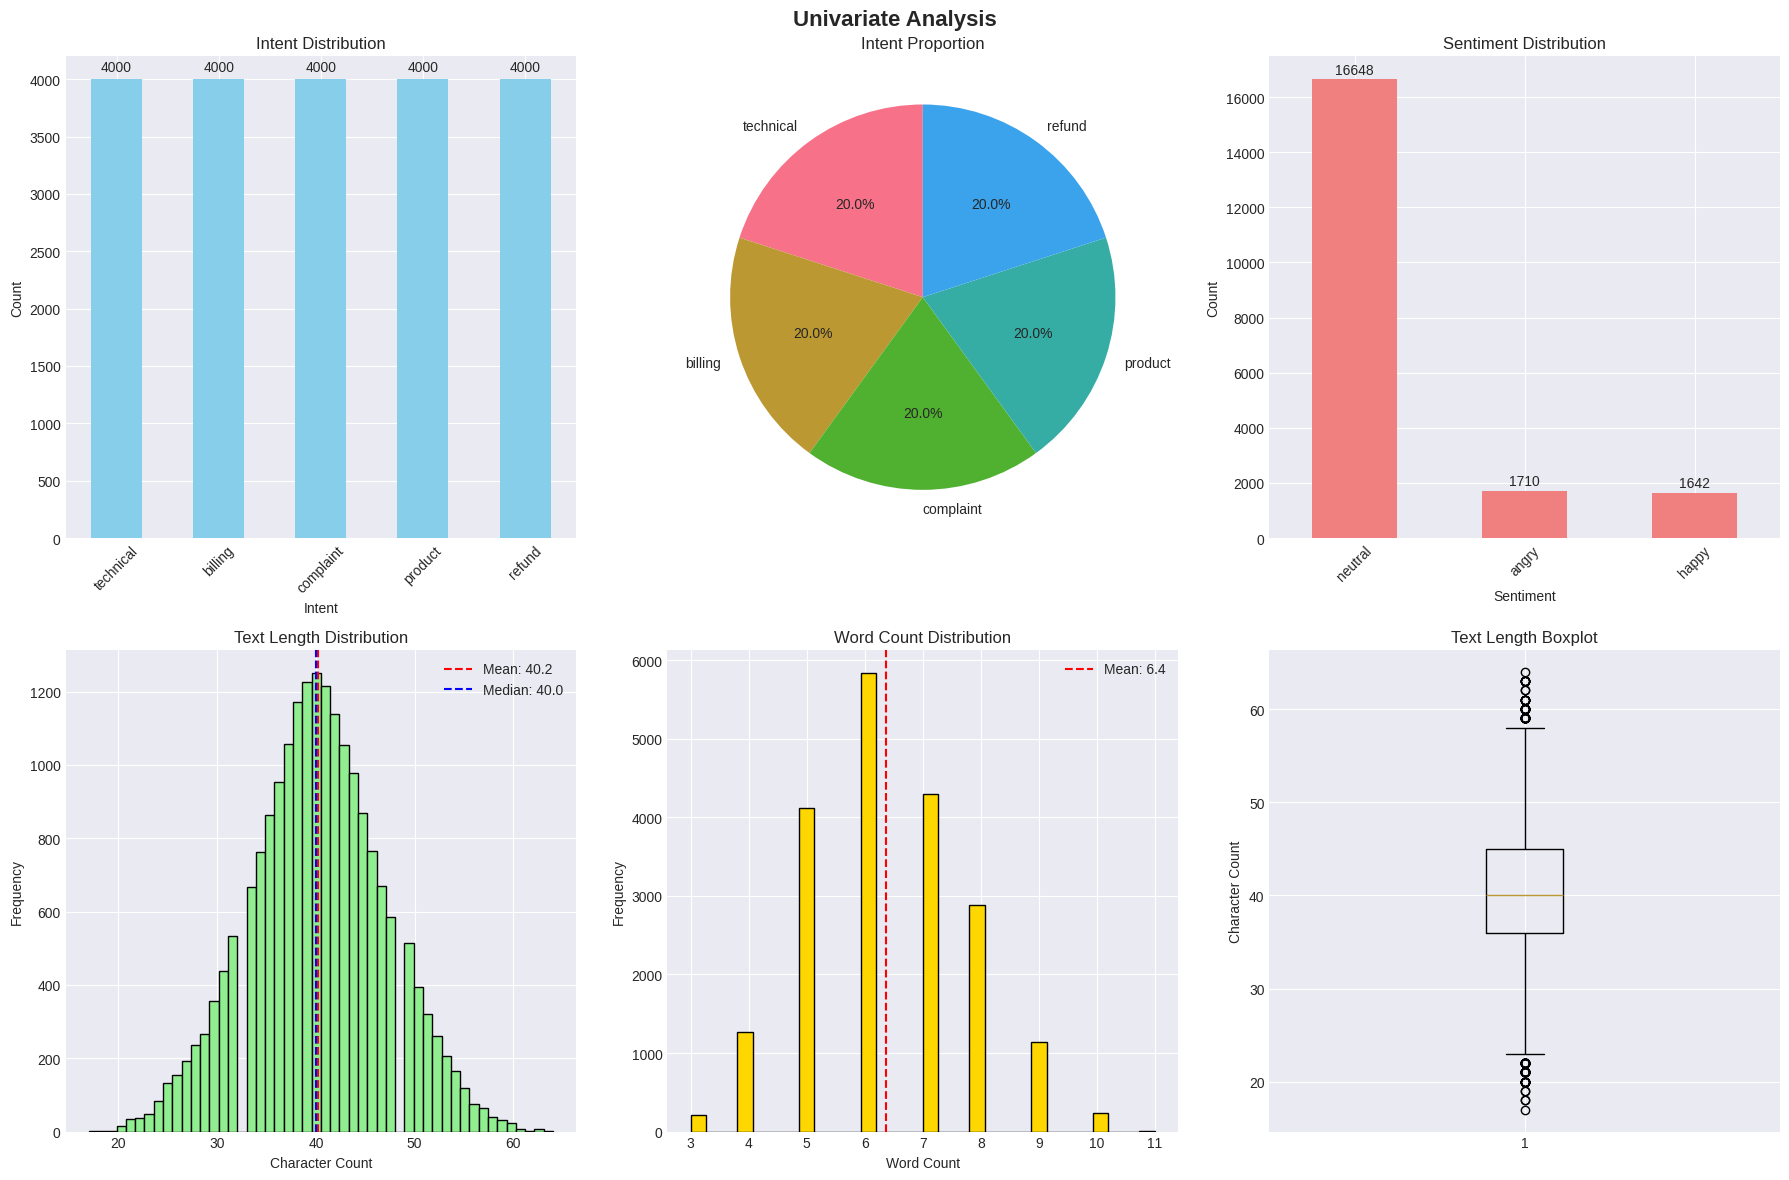


2. BIVARIATE ANALYSIS

🔄 SENTIMENT VS INTENT:
intent     billing  complaint  product  refund  technical
sentiment                                                
angry          637       1073        0       0          0
happy            0          0     1642       0          0
neutral       3363       2927     2358    4000       4000

📊 SENTIMENT VS INTENT (Percentages):
intent     billing  complaint  product  refund  technical
sentiment                                                
angry        15.92      26.82     0.00     0.0        0.0
happy         0.00       0.00    41.05     0.0        0.0
neutral      84.08      73.18    58.95   100.0      100.0

⚠️ COMPLAINT QUERIES ANALYSIS:
Total complaints: 4,000

Complaint sentiments:
sentiment
neutral    2927
angry      1073
Name: count, dtype: int64

Sample complaint queries:
       Really disappointed with Prepaid Plus
   ZENDEnterprise Ultra quality is terrible?
  Horrible quality with ZENDEnterprise Ultra
 ZENDArchive Storage exper

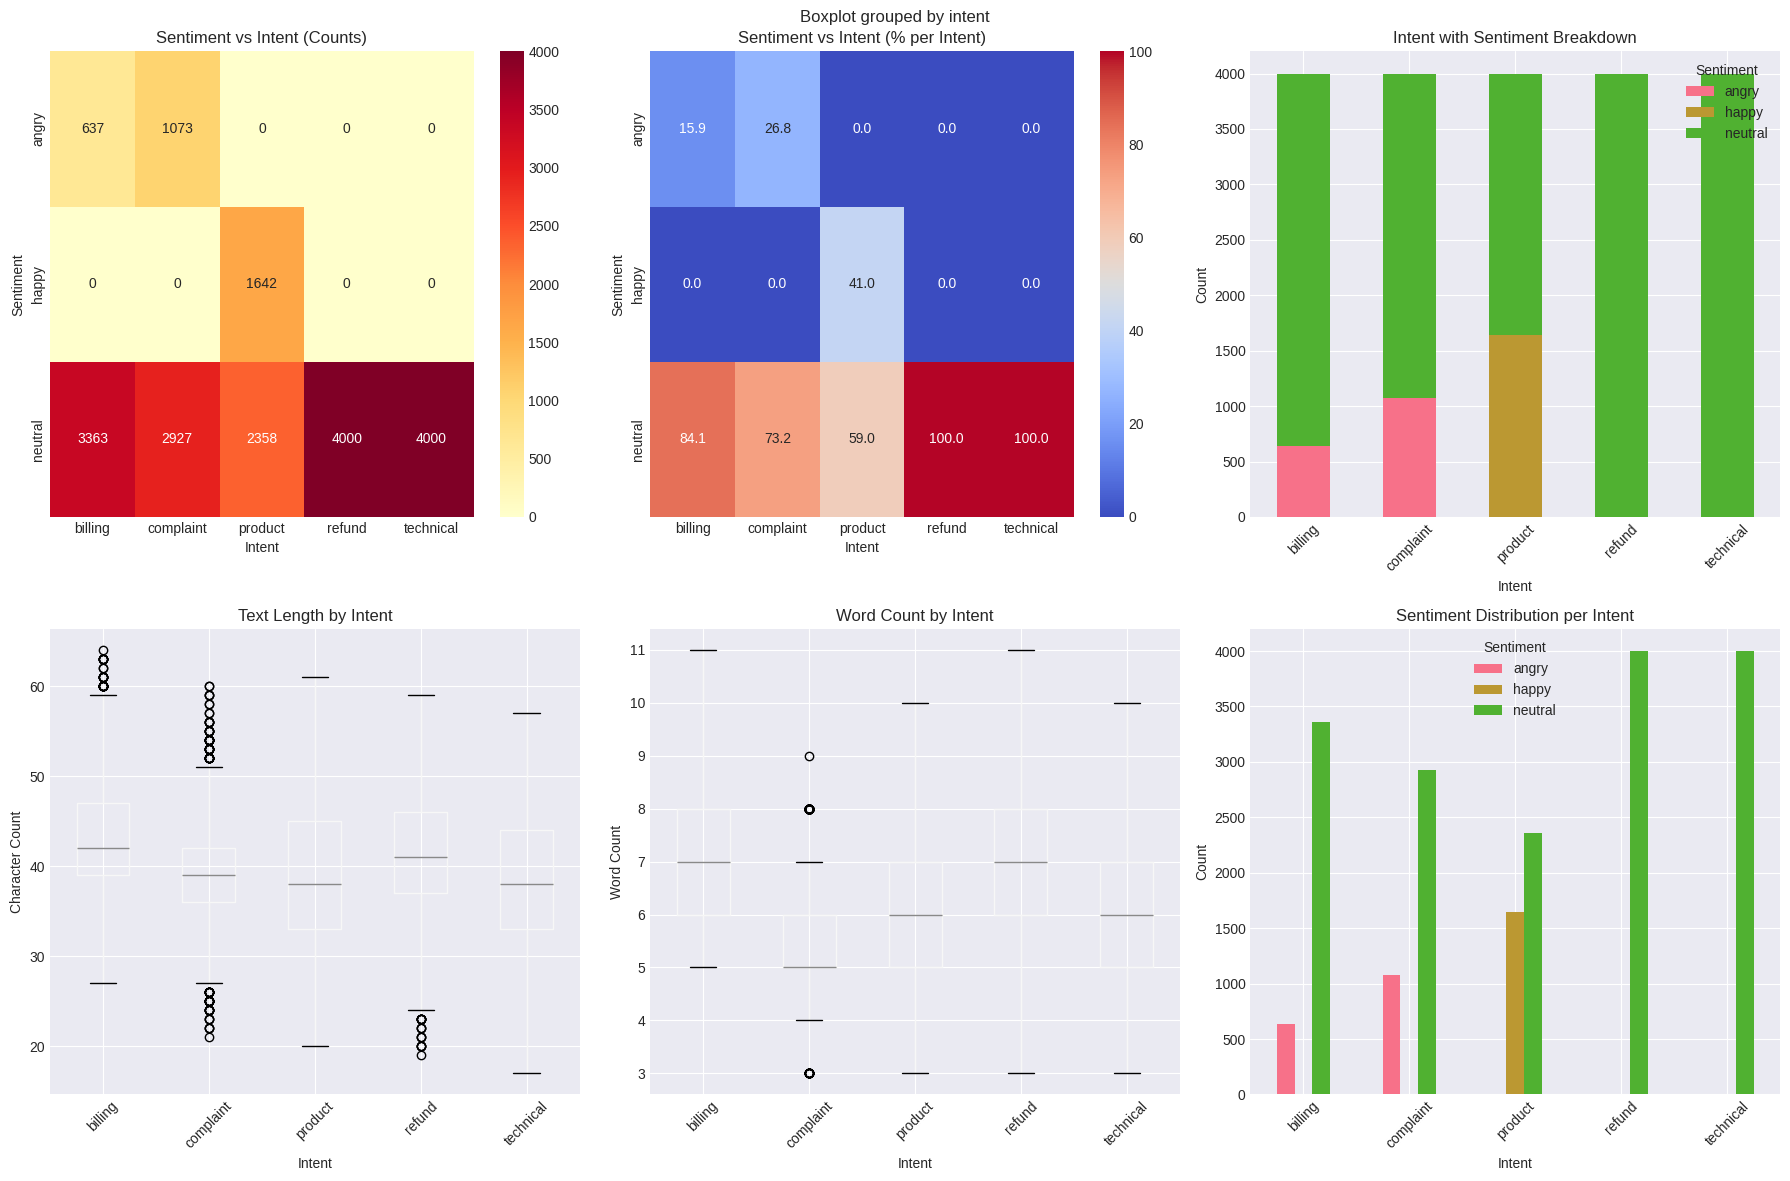


3. MULTIVARIATE ANALYSIS

🔗 INTENT × SENTIMENT × TEXT LENGTH:
                      mean  count
intent    sentiment              
billing   angry      45.97    637
          neutral    42.57   3363
complaint angry      38.75   1073
          neutral    39.28   2927
product   happy      39.20   1642
          neutral    38.79   2358
refund    neutral    41.39   4000
technical neutral    38.21   4000

📊 PIVOT: Average Text Length (Intent × Sentiment):
sentiment  angry  happy  neutral
intent                          
billing    45.97    NaN    42.57
complaint  38.75    NaN    39.28
product      NaN   39.2    38.79
refund       NaN    NaN    41.39
technical    NaN    NaN    38.21

✅ Saved: eda_3_multivariate.png


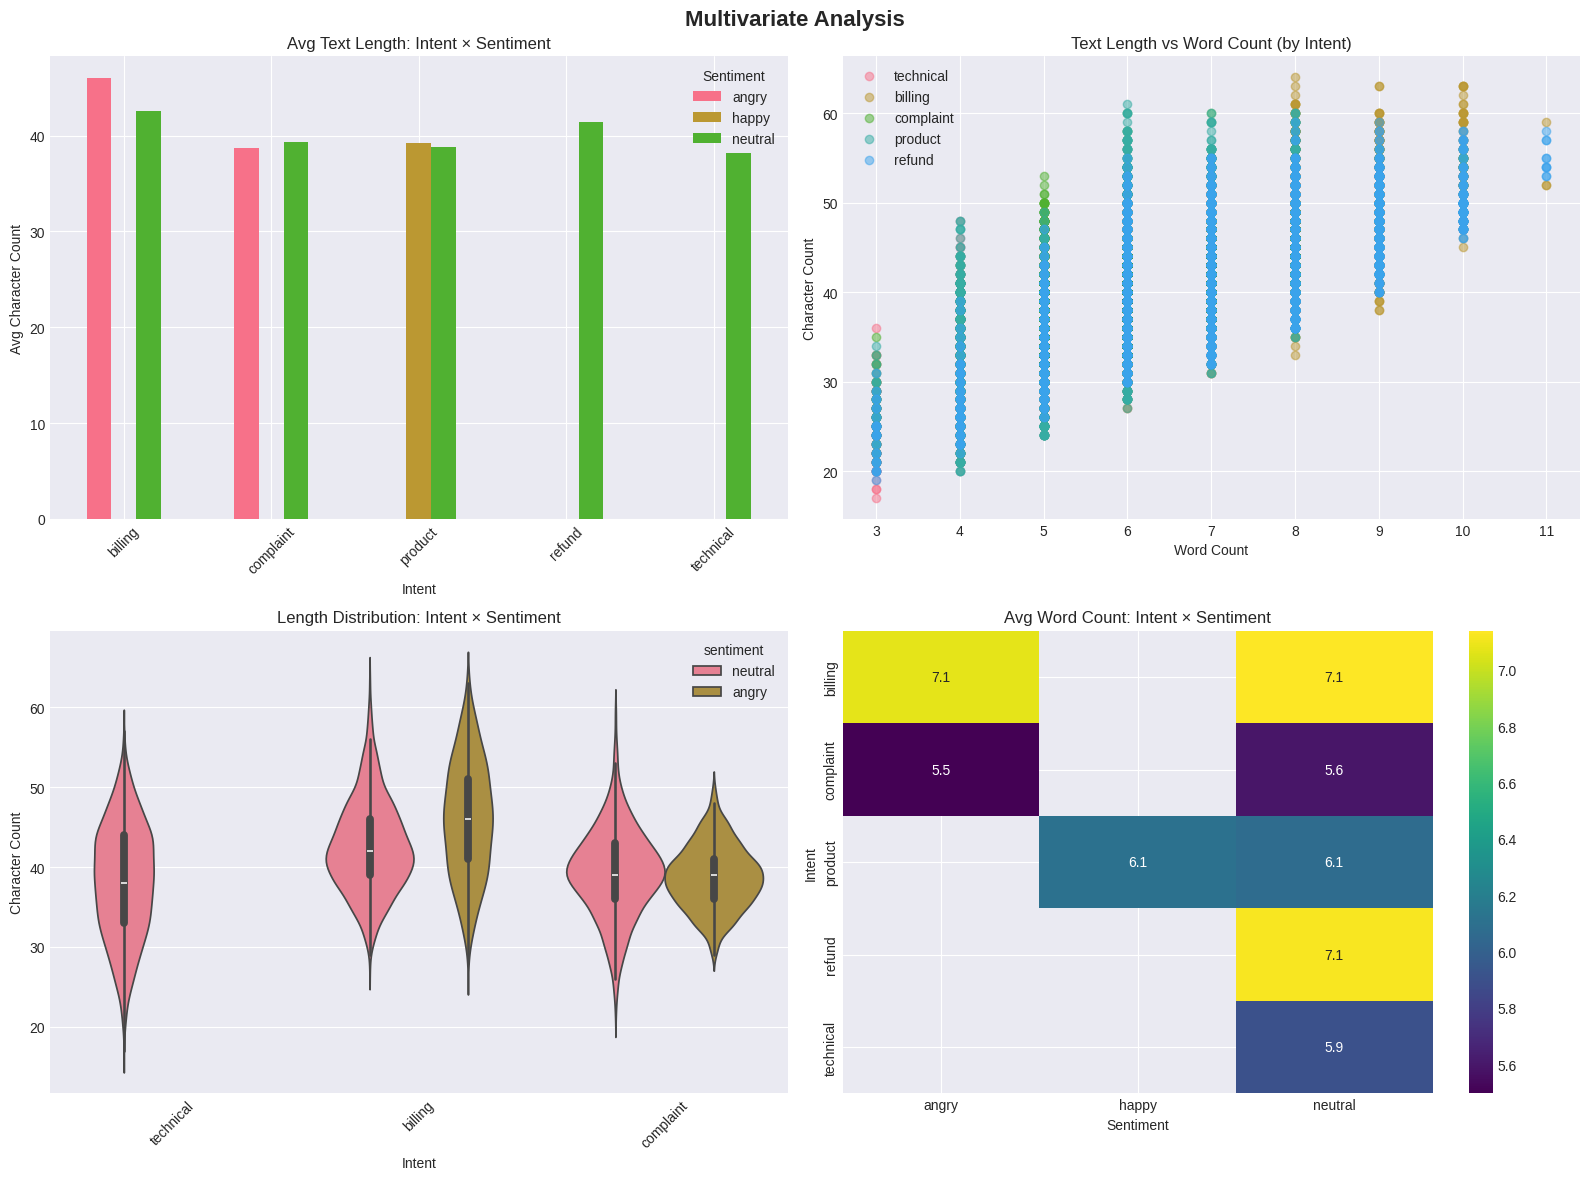


4. OUTLIER DETECTION

📏 TEXT LENGTH OUTLIERS (IQR Method):
Q1: 36.0, Q3: 45.0, IQR: 9.0
Lower bound: 22.5, Upper bound: 58.5
Outliers found: 165 (0.83%)

📊 Outlier statistics:
count    165.000000
mean      38.563636
std       19.484919
min       17.000000
25%       21.000000
50%       22.000000
75%       60.000000
max       64.000000
Name: text_length, dtype: float64

🔍 Sample unusually SHORT queries:
               text  text_length    intent
  Prepaid Plus slow           17 technical
 Postpaid Gold slow           18 technical
 Prepaid Basic slow           18 technical
Refund Prepaid Plus           19    refund
Prepaid Plus outage           19 technical

🔍 Sample unusually LONG queries:
                                                            text  text_length  intent
This billing cycle ZENDEnterprise Dedicated invoice is incorrect           64 billing
 This billing cycle ZENDFiber Home 100 Mbps billing is incorrect           63 billing
 This billing cycle ZENDFiber Home 300 Mbps 

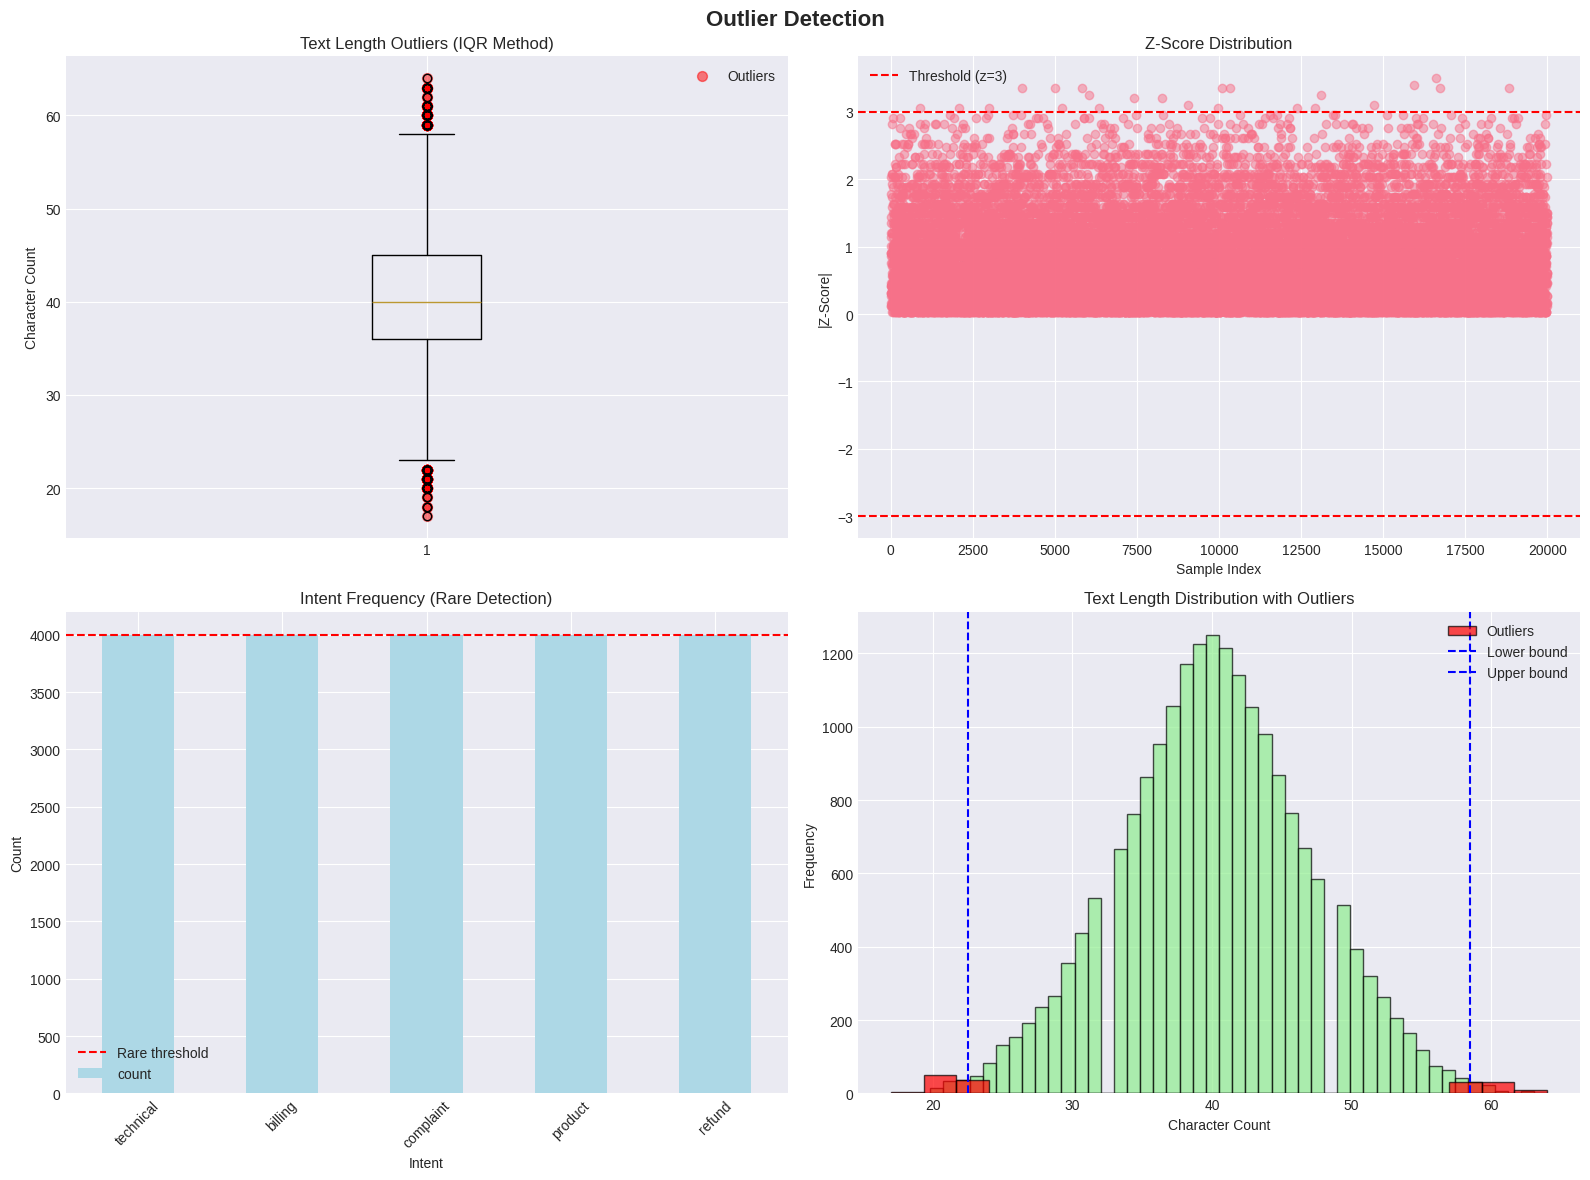


5. CORRELATION & PATTERN ANALYSIS

📊 SENTIMENT FREQUENCY PER INTENT:
sentiment  angry  happy  neutral
intent                          
billing    15.92   0.00    84.08
complaint  26.82   0.00    73.18
product     0.00  41.05    58.95
refund      0.00   0.00   100.00
technical   0.00   0.00   100.00

⚠️ HIGH-SEVERITY COMPLAINTS (Angry Sentiment):
Total high-severity complaints: 1,073 (5.37%)

Sample high-severity queries:
  ZENDEnterprise Ultra quality is terrible?
 Horrible quality with ZENDEnterprise Ultra
      ZENDSmart Traffic service is terrible
Pathetic experience with Postpaid Platinum.
     Terrible experience with Prepaid Basic
        Prepaid Plus experience is horrible
             Prepaid Basic quality is awful
     ZENDOffice Net 500 service is terrible
   ZENDBiz Connect 500 quality is terrible?
  Horrible experience with ZENDCloud VM Pro

🔗 NUMERIC FEATURE CORRELATIONS:
             text_length  word_count  char_count
text_length        1.000       0.689       1.000
wor

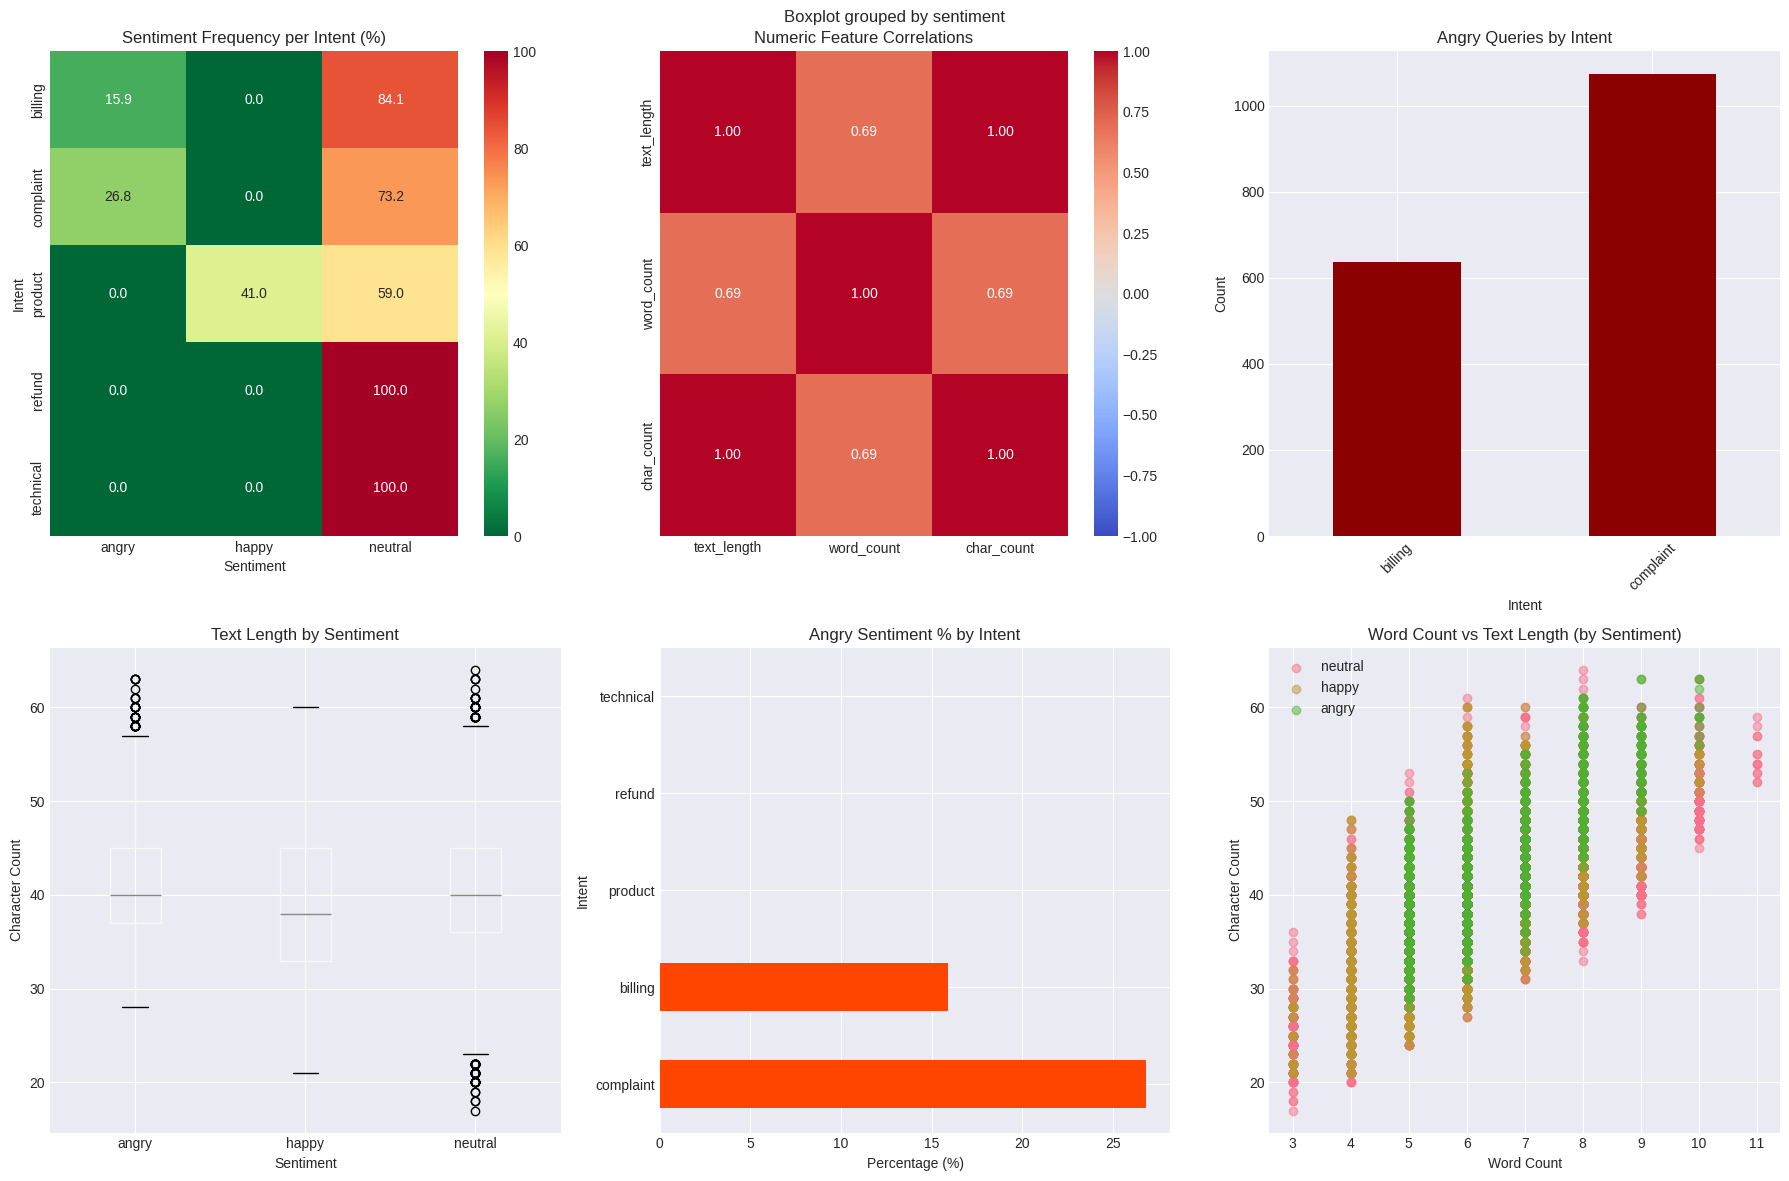


COMPREHENSIVE EDA SUMMARY REPORT

📊 DATASET OVERVIEW:
   • Total Records: 20,000
   • Total Intents: 5
   • Total Sentiments: 3
   • Duplicate Records: 0
   
📈 DATA QUALITY:
   • Missing Values: 0
   • Unique Queries: 20,000 (100.00%)
   • Duplicate Rate: 0.00%
   
📏 TEXT STATISTICS:
   • Avg Text Length: 40.2 characters
   • Avg Word Count: 6.4 words
   • Shortest Query: 17 chars
   • Longest Query: 64 chars
   
🎯 INTENT BALANCE:

   • technical: 4,000 (20.0%)
   • billing: 4,000 (20.0%)
   • complaint: 4,000 (20.0%)
   • product: 4,000 (20.0%)
   • refund: 4,000 (20.0%)

😊 SENTIMENT DISTRIBUTION:
   • Angry: 1,710 (8.6%)
   • Neutral: 16,648 (83.2%)
   • Happy: 1,642 (8.2%)
   
⚠️ KEY FINDINGS:
   • High-severity complaints: 1,073
   • Refund requests: 4,000
   • Technical issues: 4,000
   • Most angry intent: complaint
   • Longest avg queries: billing
   
✅ DATASET QUALITY SCORE:
   • Balance: ✅ Excellent
   • Uniqueness: ✅ Excellent
   • Completeness: ✅ Complete
   
🎯 READY FOR T

In [2]:
"""
ZENDS Synthetic Dataset - Exploratory Data Analysis (EDA)
Complete analysis with visualizations and insights

Covers:
1. Univariate Analysis: Distributions
2. Bivariate Analysis: Relationships
3. Multivariate Analysis: Interactions
4. Outlier Detection: Anomalies
5. Correlation Analysis: Patterns

Run this to understand your dataset before training models
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure plot sizes
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# ==================== LOAD DATA ====================

def load_data(filepath):
    """Load and basic info"""
    print("=" * 80)
    print("LOADING DATASET")
    print("=" * 80)

    df = pd.read_csv(r"/content/zends_synthetic_dataset.csv")

    print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\n📋 Columns: {list(df.columns)}")
    print(f"\n🔍 Data Types:\n{df.dtypes}")
    print(f"\n❓ Missing Values:\n{df.isnull().sum()}")
    print(f"\n📈 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Add derived features
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    df['char_count'] = df['text'].str.len()

    print(f"\n✅ Added derived features: text_length, word_count, char_count")

    return df

# ==================== 1. UNIVARIATE ANALYSIS ====================

def univariate_analysis(df):
    """Analyze single variables"""
    print("\n" + "=" * 80)
    print("1. UNIVARIATE ANALYSIS")
    print("=" * 80)

    # Intent Distribution
    print("\n📊 INTENT DISTRIBUTION:")
    intent_counts = df['intent'].value_counts()
    intent_pct = df['intent'].value_counts(normalize=True) * 100

    intent_df = pd.DataFrame({
        'Count': intent_counts,
        'Percentage': intent_pct.round(2)
    })
    print(intent_df)

    # Sentiment Distribution
    print("\n😊 SENTIMENT DISTRIBUTION:")
    sentiment_counts = df['sentiment'].value_counts()
    sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

    sentiment_df = pd.DataFrame({
        'Count': sentiment_counts,
        'Percentage': sentiment_pct.round(2)
    })
    print(sentiment_df)

    # Message Length Distribution
    print("\n📏 MESSAGE LENGTH STATISTICS:")
    print(df['text_length'].describe())
    print(f"\nMode (most common length): {df['text_length'].mode().values[0]}")
    print(f"Skewness: {df['text_length'].skew():.2f}")
    print(f"Kurtosis: {df['text_length'].kurtosis():.2f}")

    # Word Count Distribution
    print("\n📝 WORD COUNT STATISTICS:")
    print(df['word_count'].describe())

    # Visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

    # Intent bar chart
    intent_counts.plot(kind='bar', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Intent Distribution')
    axes[0, 0].set_xlabel('Intent')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(intent_counts):
        axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom')

    # Intent pie chart
    axes[0, 1].pie(intent_counts, labels=intent_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Intent Proportion')

    # Sentiment bar chart
    sentiment_counts.plot(kind='bar', ax=axes[0, 2], color='lightcoral')
    axes[0, 2].set_title('Sentiment Distribution')
    axes[0, 2].set_xlabel('Sentiment')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].tick_params(axis='x', rotation=45)
    for i, v in enumerate(sentiment_counts):
        axes[0, 2].text(i, v + 100, str(v), ha='center', va='bottom')

    # Text length histogram
    axes[1, 0].hist(df['text_length'], bins=50, color='lightgreen', edgecolor='black')
    axes[1, 0].set_title('Text Length Distribution')
    axes[1, 0].set_xlabel('Character Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.1f}')
    axes[1, 0].axvline(df['text_length'].median(), color='blue', linestyle='--', label=f'Median: {df["text_length"].median():.1f}')
    axes[1, 0].legend()

    # Word count histogram
    axes[1, 1].hist(df['word_count'], bins=30, color='gold', edgecolor='black')
    axes[1, 1].set_title('Word Count Distribution')
    axes[1, 1].set_xlabel('Word Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
    axes[1, 1].legend()

    # Text length boxplot
    axes[1, 2].boxplot(df['text_length'], vert=True)
    axes[1, 2].set_title('Text Length Boxplot')
    axes[1, 2].set_ylabel('Character Count')

    plt.tight_layout()
    plt.savefig('eda_1_univariate.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_1_univariate.png")
    plt.show()

# ==================== 2. BIVARIATE ANALYSIS ====================

def bivariate_analysis(df):
    """Analyze relationships between two variables"""
    print("\n" + "=" * 80)
    print("2. BIVARIATE ANALYSIS")
    print("=" * 80)

    # Sentiment vs Intent
    print("\n🔄 SENTIMENT VS INTENT:")
    sentiment_intent = pd.crosstab(df['sentiment'], df['intent'])
    print(sentiment_intent)

    print("\n📊 SENTIMENT VS INTENT (Percentages):")
    sentiment_intent_pct = pd.crosstab(df['sentiment'], df['intent'], normalize='columns') * 100
    print(sentiment_intent_pct.round(2))

    # Common Complaints
    print("\n⚠️ COMPLAINT QUERIES ANALYSIS:")
    complaints = df[df['intent'] == 'complaint']
    print(f"Total complaints: {len(complaints):,}")
    print(f"\nComplaint sentiments:")
    print(complaints['sentiment'].value_counts())
    print(f"\nSample complaint queries:")
    print(complaints['text'].head(10).to_string(index=False))

    # Refund-related Queries
    print("\n💰 REFUND QUERIES ANALYSIS:")
    refunds = df[df['intent'] == 'refund']
    print(f"Total refund requests: {len(refunds):,}")
    print(f"\nRefund sentiments:")
    print(refunds['sentiment'].value_counts())
    print(f"\nSample refund queries:")
    print(refunds['text'].head(10).to_string(index=False))

    # Message length by intent
    print("\n📏 MESSAGE LENGTH BY INTENT:")
    length_by_intent = df.groupby('intent')['text_length'].agg(['mean', 'median', 'std', 'min', 'max'])
    print(length_by_intent.round(2))

    # Visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

    # Sentiment vs Intent heatmap
    sns.heatmap(sentiment_intent, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 0])
    axes[0, 0].set_title('Sentiment vs Intent (Counts)')
    axes[0, 0].set_xlabel('Intent')
    axes[0, 0].set_ylabel('Sentiment')

    # Sentiment vs Intent (normalized)
    sns.heatmap(sentiment_intent_pct, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Sentiment vs Intent (% per Intent)')
    axes[0, 1].set_xlabel('Intent')
    axes[0, 1].set_ylabel('Sentiment')

    # Stacked bar chart
    sentiment_intent.T.plot(kind='bar', stacked=True, ax=axes[0, 2])
    axes[0, 2].set_title('Intent with Sentiment Breakdown')
    axes[0, 2].set_xlabel('Intent')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].legend(title='Sentiment')
    axes[0, 2].tick_params(axis='x', rotation=45)

    # Message length by intent boxplot
    df.boxplot(column='text_length', by='intent', ax=axes[1, 0])
    axes[1, 0].set_title('Text Length by Intent')
    axes[1, 0].set_xlabel('Intent')
    axes[1, 0].set_ylabel('Character Count')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45)

    # Word count by intent
    df.boxplot(column='word_count', by='intent', ax=axes[1, 1])
    axes[1, 1].set_title('Word Count by Intent')
    axes[1, 1].set_xlabel('Intent')
    axes[1, 1].set_ylabel('Word Count')
    plt.sca(axes[1, 1])
    plt.xticks(rotation=45)

    # Sentiment distribution per intent
    sentiment_by_intent = df.groupby(['intent', 'sentiment']).size().unstack(fill_value=0)
    sentiment_by_intent.plot(kind='bar', ax=axes[1, 2])
    axes[1, 2].set_title('Sentiment Distribution per Intent')
    axes[1, 2].set_xlabel('Intent')
    axes[1, 2].set_ylabel('Count')
    axes[1, 2].legend(title='Sentiment')
    axes[1, 2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('eda_2_bivariate.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_2_bivariate.png")
    plt.show()

# ==================== 3. MULTIVARIATE ANALYSIS ====================

def multivariate_analysis(df):
    """Analyze interactions between multiple variables"""
    print("\n" + "=" * 80)
    print("3. MULTIVARIATE ANALYSIS")
    print("=" * 80)

    # Message length, intent, sentiment interaction
    print("\n🔗 INTENT × SENTIMENT × TEXT LENGTH:")
    interaction = df.groupby(['intent', 'sentiment'])['text_length'].agg(['mean', 'count'])
    print(interaction.round(2))

    # Pivot table
    print("\n📊 PIVOT: Average Text Length (Intent × Sentiment):")
    pivot = df.pivot_table(values='text_length', index='intent', columns='sentiment', aggfunc='mean')
    print(pivot.round(2))

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Multivariate Analysis', fontsize=16, fontweight='bold')

    # 3D-like visualization: Intent × Sentiment × Length
    pivot.plot(kind='bar', ax=axes[0, 0])
    axes[0, 0].set_title('Avg Text Length: Intent × Sentiment')
    axes[0, 0].set_xlabel('Intent')
    axes[0, 0].set_ylabel('Avg Character Count')
    axes[0, 0].legend(title='Sentiment')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Scatter plot: Text length vs Word count (colored by intent)
    for intent in df['intent'].unique():
        intent_data = df[df['intent'] == intent]
        axes[0, 1].scatter(intent_data['word_count'], intent_data['text_length'],
                          label=intent, alpha=0.5)
    axes[0, 1].set_title('Text Length vs Word Count (by Intent)')
    axes[0, 1].set_xlabel('Word Count')
    axes[0, 1].set_ylabel('Character Count')
    axes[0, 1].legend()

    # Violin plot: Length distribution by intent and sentiment
    # Filter for top 3 intents for clarity
    top_intents = df['intent'].value_counts().head(3).index
    df_subset = df[df['intent'].isin(top_intents)]

    sns.violinplot(data=df_subset, x='intent', y='text_length', hue='sentiment',
                   split=False, ax=axes[1, 0])
    axes[1, 0].set_title('Length Distribution: Intent × Sentiment')
    axes[1, 0].set_xlabel('Intent')
    axes[1, 0].set_ylabel('Character Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Heatmap: Average word count
    pivot_words = df.pivot_table(values='word_count', index='intent', columns='sentiment', aggfunc='mean')
    sns.heatmap(pivot_words, annot=True, fmt='.1f', cmap='viridis', ax=axes[1, 1])
    axes[1, 1].set_title('Avg Word Count: Intent × Sentiment')
    axes[1, 1].set_xlabel('Sentiment')
    axes[1, 1].set_ylabel('Intent')

    plt.tight_layout()
    plt.savefig('eda_3_multivariate.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_3_multivariate.png")
    plt.show()

# ==================== 4. OUTLIER DETECTION ====================

def outlier_detection(df):
    """Detect anomalies and outliers"""
    print("\n" + "=" * 80)
    print("4. OUTLIER DETECTION")
    print("=" * 80)

    # Text length outliers (using IQR method)
    Q1 = df['text_length'].quantile(0.25)
    Q3 = df['text_length'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_length = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]

    print(f"\n📏 TEXT LENGTH OUTLIERS (IQR Method):")
    print(f"Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
    print(f"Lower bound: {lower_bound:.1f}, Upper bound: {upper_bound:.1f}")
    print(f"Outliers found: {len(outliers_length):,} ({len(outliers_length)/len(df)*100:.2f}%)")

    if len(outliers_length) > 0:
        print(f"\n📊 Outlier statistics:")
        print(outliers_length['text_length'].describe())

        print(f"\n🔍 Sample unusually SHORT queries:")
        short_outliers = outliers_length.nsmallest(5, 'text_length')[['text', 'text_length', 'intent']]
        print(short_outliers.to_string(index=False))

        print(f"\n🔍 Sample unusually LONG queries:")
        long_outliers = outliers_length.nlargest(5, 'text_length')[['text', 'text_length', 'intent']]
        print(long_outliers.to_string(index=False))

    # Rare intents (statistical outliers)
    print(f"\n🔍 RARE INTENT DETECTION:")
    intent_counts = df['intent'].value_counts()
    mean_count = intent_counts.mean()
    std_count = intent_counts.std()

    print(f"Mean intent count: {mean_count:.1f}")
    print(f"Std deviation: {std_count:.1f}")

    rare_threshold = mean_count - 2 * std_count
    rare_intents = intent_counts[intent_counts < rare_threshold]

    if len(rare_intents) > 0:
        print(f"\n⚠️ Rare intents (< 2 std from mean):")
        print(rare_intents)
    else:
        print(f"\n✅ No statistically rare intents detected (all within 2σ)")

    # Z-score based outliers
    df['text_length_zscore'] = np.abs(stats.zscore(df['text_length']))
    outliers_zscore = df[df['text_length_zscore'] > 3]

    print(f"\n📊 Z-SCORE OUTLIERS (|z| > 3):")
    print(f"Outliers found: {len(outliers_zscore):,} ({len(outliers_zscore)/len(df)*100:.2f}%)")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Outlier Detection', fontsize=16, fontweight='bold')

    # Boxplot with outliers highlighted
    axes[0, 0].boxplot(df['text_length'], vert=True)
    axes[0, 0].scatter([1]*len(outliers_length), outliers_length['text_length'],
                      color='red', s=50, alpha=0.5, label='Outliers')
    axes[0, 0].set_title('Text Length Outliers (IQR Method)')
    axes[0, 0].set_ylabel('Character Count')
    axes[0, 0].legend()

    # Z-score plot
    axes[0, 1].scatter(range(len(df)), df['text_length_zscore'], alpha=0.5)
    axes[0, 1].axhline(y=3, color='r', linestyle='--', label='Threshold (z=3)')
    axes[0, 1].axhline(y=-3, color='r', linestyle='--')
    axes[0, 1].set_title('Z-Score Distribution')
    axes[0, 1].set_xlabel('Sample Index')
    axes[0, 1].set_ylabel('|Z-Score|')
    axes[0, 1].legend()

    # Intent frequency (detect rare intents)
    intent_counts.plot(kind='bar', ax=axes[1, 0], color='lightblue')
    axes[1, 0].axhline(y=rare_threshold, color='r', linestyle='--', label=f'Rare threshold')
    axes[1, 0].set_title('Intent Frequency (Rare Detection)')
    axes[1, 0].set_xlabel('Intent')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend()

    # Histogram with outliers marked
    axes[1, 1].hist(df['text_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    if len(outliers_length) > 0:
        axes[1, 1].hist(outliers_length['text_length'], bins=20, color='red',
                       edgecolor='black', alpha=0.7, label='Outliers')
    axes[1, 1].axvline(lower_bound, color='blue', linestyle='--', label='Lower bound')
    axes[1, 1].axvline(upper_bound, color='blue', linestyle='--', label='Upper bound')
    axes[1, 1].set_title('Text Length Distribution with Outliers')
    axes[1, 1].set_xlabel('Character Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('eda_4_outliers.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_4_outliers.png")
    plt.show()

    # Clean up temporary column
    df.drop('text_length_zscore', axis=1, inplace=True)

# ==================== 5. CORRELATION ANALYSIS ====================

def correlation_analysis(df):
    """Analyze patterns and correlations"""
    print("\n" + "=" * 80)
    print("5. CORRELATION & PATTERN ANALYSIS")
    print("=" * 80)

    # Sentiment frequency per intent
    print("\n📊 SENTIMENT FREQUENCY PER INTENT:")
    sentiment_freq = pd.crosstab(df['intent'], df['sentiment'], normalize='index') * 100
    print(sentiment_freq.round(2))

    # High-severity complaints (angry + complaint)
    print("\n⚠️ HIGH-SEVERITY COMPLAINTS (Angry Sentiment):")
    high_severity = df[(df['intent'] == 'complaint') & (df['sentiment'] == 'angry')]
    print(f"Total high-severity complaints: {len(high_severity):,} ({len(high_severity)/len(df)*100:.2f}%)")
    print(f"\nSample high-severity queries:")
    print(high_severity['text'].head(10).to_string(index=False))

    # Correlation between numeric features
    print("\n🔗 NUMERIC FEATURE CORRELATIONS:")
    numeric_cols = ['text_length', 'word_count', 'char_count']
    corr_matrix = df[numeric_cols].corr()
    print(corr_matrix.round(3))

    # Pattern: Intent with most angry sentiment
    print("\n😠 INTENTS WITH HIGHEST ANGRY SENTIMENT:")
    angry_by_intent = df[df['sentiment'] == 'angry'].groupby('intent').size().sort_values(ascending=False)
    angry_pct = (angry_by_intent / df.groupby('intent').size() * 100).sort_values(ascending=False)

    angry_analysis = pd.DataFrame({
        'Angry Count': angry_by_intent,
        'Angry %': angry_pct.round(2)
    })
    print(angry_analysis)

    # Pattern: Average length by sentiment
    print("\n📏 AVERAGE TEXT LENGTH BY SENTIMENT:")
    length_by_sentiment = df.groupby('sentiment')['text_length'].agg(['mean', 'median', 'std'])
    print(length_by_sentiment.round(2))

    # Visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Correlation & Pattern Analysis', fontsize=16, fontweight='bold')

    # Sentiment frequency heatmap
    sns.heatmap(sentiment_freq, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[0, 0])
    axes[0, 0].set_title('Sentiment Frequency per Intent (%)')
    axes[0, 0].set_xlabel('Sentiment')
    axes[0, 0].set_ylabel('Intent')

    # Correlation heatmap
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1],
               vmin=-1, vmax=1, center=0)
    axes[0, 1].set_title('Numeric Feature Correlations')

    # High-severity by intent
    high_sev_by_intent = df[(df['sentiment'] == 'angry')].groupby('intent').size()
    high_sev_by_intent.plot(kind='bar', ax=axes[0, 2], color='darkred')
    axes[0, 2].set_title('Angry Queries by Intent')
    axes[0, 2].set_xlabel('Intent')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].tick_params(axis='x', rotation=45)

    # Length vs sentiment
    df.boxplot(column='text_length', by='sentiment', ax=axes[1, 0])
    axes[1, 0].set_title('Text Length by Sentiment')
    axes[1, 0].set_xlabel('Sentiment')
    axes[1, 0].set_ylabel('Character Count')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=0)

    # Angry percentage by intent
    angry_pct.plot(kind='barh', ax=axes[1, 1], color='orangered')
    axes[1, 1].set_title('Angry Sentiment % by Intent')
    axes[1, 1].set_xlabel('Percentage (%)')
    axes[1, 1].set_ylabel('Intent')

    # Scatter: Word count vs sentiment (encoded)
    sentiment_mapping = {'angry': 0, 'neutral': 1, 'happy': 2}
    df['sentiment_encoded'] = df['sentiment'].map(sentiment_mapping)

    for sentiment in df['sentiment'].unique():
        sentiment_data = df[df['sentiment'] == sentiment]
        axes[1, 2].scatter(sentiment_data['word_count'], sentiment_data['text_length'],
                          label=sentiment, alpha=0.5)
    axes[1, 2].set_title('Word Count vs Text Length (by Sentiment)')
    axes[1, 2].set_xlabel('Word Count')
    axes[1, 2].set_ylabel('Character Count')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.savefig('eda_5_correlation.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_5_correlation.png")
    plt.show()

    # Clean up
    df.drop('sentiment_encoded', axis=1, inplace=True)

# ==================== SUMMARY REPORT ====================

def generate_summary_report(df):
    """Generate comprehensive summary"""
    print("\n" + "=" * 80)
    print("COMPREHENSIVE EDA SUMMARY REPORT")
    print("=" * 80)

    print(f"""
📊 DATASET OVERVIEW:
   • Total Records: {len(df):,}
   • Total Intents: {df['intent'].nunique()}
   • Total Sentiments: {df['sentiment'].nunique()}
   • Duplicate Records: {df.duplicated().sum()}

📈 DATA QUALITY:
   • Missing Values: {df.isnull().sum().sum()}
   • Unique Queries: {df['text'].nunique():,} ({df['text'].nunique()/len(df)*100:.2f}%)
   • Duplicate Rate: {(1 - df['text'].nunique()/len(df))*100:.2f}%

📏 TEXT STATISTICS:
   • Avg Text Length: {df['text_length'].mean():.1f} characters
   • Avg Word Count: {df['word_count'].mean():.1f} words
   • Shortest Query: {df['text_length'].min()} chars
   • Longest Query: {df['text_length'].max()} chars

🎯 INTENT BALANCE:
""")
    intent_balance = df['intent'].value_counts()
    for intent, count in intent_balance.items():
        print(f"   • {intent}: {count:,} ({count/len(df)*100:.1f}%)")

    print(f"""
😊 SENTIMENT DISTRIBUTION:
   • Angry: {len(df[df['sentiment']=='angry']):,} ({len(df[df['sentiment']=='angry'])/len(df)*100:.1f}%)
   • Neutral: {len(df[df['sentiment']=='neutral']):,} ({len(df[df['sentiment']=='neutral'])/len(df)*100:.1f}%)
   • Happy: {len(df[df['sentiment']=='happy']):,} ({len(df[df['sentiment']=='happy'])/len(df)*100:.1f}%)

⚠️ KEY FINDINGS:
   • High-severity complaints: {len(df[(df['intent']=='complaint') & (df['sentiment']=='angry')]):,}
   • Refund requests: {len(df[df['intent']=='refund']):,}
   • Technical issues: {len(df[df['intent']=='technical']):,}
   • Most angry intent: {df[df['sentiment']=='angry']['intent'].mode().values[0]}
   • Longest avg queries: {df.groupby('intent')['text_length'].mean().idxmax()}

✅ DATASET QUALITY SCORE:
   • Balance: {'✅ Excellent' if intent_balance.std() < 100 else '⚠️ Needs improvement'}
   • Uniqueness: {'✅ Excellent' if df['text'].nunique()/len(df) > 0.95 else '⚠️ Moderate'}
   • Completeness: {'✅ Complete' if df.isnull().sum().sum() == 0 else '⚠️ Has missing'}

🎯 READY FOR TRAINING: ✅ YES
""")

# ==================== MAIN EXECUTION ====================

def main():
    """Main EDA execution"""
    print("\n" + "🔍" * 40)
    print("ZENDS SYNTHETIC DATASET - EXPLORATORY DATA ANALYSIS")
    print("🔍" * 40 + "\n")

    # Get filepath
    filepath = input("Enter path to zends synthetic dataset CSV (or press Enter for 'zends_synthetic_dataset.csv'): ").strip()
    if not filepath:
        filepath = r"/content/zends_synthetic_dataset.csv"

    try:
        # Load data
        df = load_data(filepath)

        # Run all analyses
        univariate_analysis(df)
        bivariate_analysis(df)
        multivariate_analysis(df)
        outlier_detection(df)
        correlation_analysis(df)

        # Generate summary
        generate_summary_report(df)

        print("\n" + "=" * 80)
        print("✅ EDA COMPLETE!")
        print("=" * 80)
        print("""
📁 Generated files:
   • eda_1_univariate.png
   • eda_2_bivariate.png
   • eda_3_multivariate.png
   • eda_4_outliers.png
   • eda_5_correlation.png

💡 Next steps:
   1. Review all visualizations
   2. Check for data quality issues
   3. Proceed with model training
   4. Monitor model performance
""")

    except FileNotFoundError:
        print(f"\n❌ Error: File '{filepath}' not found!")
        print("Please check the file path and try again.")
    except Exception as e:
        print(f"\n❌ Error during EDA: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [3]:
"""
ZENDS Intent Model - DEBUG VERSION
This will show exactly where the KeyError occurs
"""

import pandas as pd
import numpy as np
import json
import os
import traceback
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

def detect_device():
    if torch.cuda.is_available():
        return 'cuda', 'GPU'
    try:
        import torch_xla.core.xla_model as xm
        return 'xla', 'TPU'
    except ImportError:
        return 'cpu', 'CPU'

DEVICE_TYPE, DEVICE_NAME = detect_device()
print(f"Device: {DEVICE_NAME}")

import transformers
print(f"Transformers: {transformers.__version__}")

class Config:
    MODEL_OPTIONS = {
        '1': 'distilbert-base-uncased',
        '2': 'bert-base-uncased',
        '3': 'roberta-base'
    }

    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 5
    WEIGHT_DECAY = 0.01
    WARMUP_STEPS = 500
    MAX_LENGTH = 128
    OUTPUT_DIR = './intent_model'

def load_data(filepath):
    print("\n" + "=" * 70)
    print("LOADING DATA")
    print("=" * 70)

    try:
        df = pd.read_csv(r"/content/zends_synthetic_dataset.csv")
        print(f"✅ Loaded: {len(df):,} records")

        if 'text' not in df.columns or 'intent' not in df.columns:
            raise ValueError("Need 'text' and 'intent' columns!")

        print(f"\n🎯 Intents:")
        for intent, count in df['intent'].value_counts().items():
            print(f"   {intent}: {count:,}")

        df = df.dropna(subset=['text', 'intent'])
        print(f"✅ After cleaning: {len(df):,} records")
        return df

    except Exception as e:
        print(f"❌ ERROR in load_data: {e}")
        traceback.print_exc()
        raise

def create_label_encoder(df):
    print("\n" + "=" * 70)
    print("CREATING LABEL ENCODER")
    print("=" * 70)

    try:
        label_encoder = LabelEncoder()
        df['label'] = label_encoder.fit_transform(df['intent'])

        print(f"\n📋 Classes: {label_encoder.classes_}")
        print(f"📋 Number of classes: {len(label_encoder.classes_)}")

        # Create mappings - ALL KEYS AS STRINGS
        label_to_id = {}
        id_to_label = {}

        for idx, label in enumerate(label_encoder.classes_):
            label_to_id[label] = idx
            id_to_label[str(idx)] = label  # String key!
            print(f"   {idx} → '{label}'")

        label_encoder_dict = {
            'label_to_id': label_to_id,
            'id_to_label': id_to_label,
            'classes': label_encoder.classes_.tolist(),
            'num_classes': len(label_encoder.classes_)
        }

        print(f"\n✅ Label encoder created")
        print(f"   label_to_id keys: {list(label_to_id.keys())}")
        print(f"   id_to_label keys: {list(id_to_label.keys())}")
        print(f"   id_to_label key types: {type(list(id_to_label.keys())[0])}")

        return label_encoder, label_encoder_dict, df

    except Exception as e:
        print(f"❌ ERROR in create_label_encoder: {e}")
        traceback.print_exc()
        raise

def split_data(df):
    print("\n" + "=" * 70)
    print("SPLITTING DATA")
    print("=" * 70)

    try:
        train_val_df, test_df = train_test_split(
            df, test_size=0.15, stratify=df['label'], random_state=42
        )
        train_df, val_df = train_test_split(
            train_val_df, test_size=0.176, stratify=train_val_df['label'], random_state=42
        )

        print(f"✅ Train: {len(train_df):,}")
        print(f"✅ Val:   {len(val_df):,}")
        print(f"✅ Test:  {len(test_df):,}")

        return train_df, val_df, test_df

    except Exception as e:
        print(f"❌ ERROR in split_data: {e}")
        traceback.print_exc()
        raise

def prepare_datasets(train_df, val_df, test_df, tokenizer, max_length=128):
    print("\n" + "=" * 70)
    print("TOKENIZING")
    print("=" * 70)

    try:
        def tokenize(examples):
            return tokenizer(examples['text'], padding='max_length',
                           truncation=True, max_length=max_length)

        print("Creating datasets...")
        train_ds = Dataset.from_pandas(train_df[['text', 'label']])
        val_ds = Dataset.from_pandas(val_df[['text', 'label']])
        test_ds = Dataset.from_pandas(test_df[['text', 'label']])

        print("Tokenizing...")
        train_ds = train_ds.map(tokenize, batched=True)
        val_ds = val_ds.map(tokenize, batched=True)
        test_ds = test_ds.map(tokenize, batched=True)

        print("Setting format...")
        train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
        val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
        test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

        print("✅ Done")
        return train_ds, val_ds, test_ds

    except Exception as e:
        print(f"❌ ERROR in prepare_datasets: {e}")
        traceback.print_exc()
        raise

def compute_metrics(eval_pred):
    try:
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)

        accuracy = accuracy_score(labels, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='weighted', zero_division=0
        )

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
    except Exception as e:
        print(f"❌ ERROR in compute_metrics: {e}")
        traceback.print_exc()
        raise

def create_training_args(config, device_type):
    try:
        import inspect
        sig = inspect.signature(TrainingArguments.__init__)
        params = list(sig.parameters.keys())

        args = {
            'output_dir': config.OUTPUT_DIR,
            'num_train_epochs': config.NUM_EPOCHS,
            'per_device_train_batch_size': config.BATCH_SIZE,
            'per_device_eval_batch_size': config.BATCH_SIZE * 2,
            'learning_rate': config.LEARNING_RATE,
            'weight_decay': config.WEIGHT_DECAY,
            'warmup_steps': config.WARMUP_STEPS,
            'logging_dir': f'{config.OUTPUT_DIR}/logs',
            'logging_steps': 100,
            'save_steps': 500,
            'save_total_limit': 2,
            'load_best_model_at_end': True,
            'metric_for_best_model': 'f1',
            'greater_is_better': True,
            'report_to': 'none',
        }

        if 'eval_strategy' in params:
            args['eval_strategy'] = 'steps'
            args['eval_steps'] = 500
        elif 'evaluation_strategy' in params:
            args['evaluation_strategy'] = 'steps'
            args['eval_steps'] = 500

        if 'save_strategy' in params:
            args['save_strategy'] = 'steps'

        if device_type == 'cuda':
            args['fp16'] = True
        elif device_type == 'xla':
            if 'optim' in params:
                args['optim'] = 'adamw_torch'

        if device_type != 'xla':
            args['dataloader_num_workers'] = 2

        return TrainingArguments(**args)

    except Exception as e:
        print(f"❌ ERROR in create_training_args: {e}")
        traceback.print_exc()
        raise

def train_model(train_ds, val_ds, model, config, device_type):
    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    try:
        training_args = create_training_args(config, device_type)

        print(f"✅ Args created")
        print(f"   Device: {DEVICE_NAME}")
        print(f"   Batch: {config.BATCH_SIZE}")
        print(f"   Epochs: {config.NUM_EPOCHS}")

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )

        print(f"✅ Trainer created")
        print(f"\n🚀 Starting training...")

        result = trainer.train()

        print(f"✅ Training complete")

        metrics = result.metrics
        val_metrics = trainer.evaluate()

        print(f"\n📊 Results:")
        print(f"   Loss: {metrics['train_loss']:.4f}")
        print(f"   Val Acc: {val_metrics['eval_accuracy']:.4f}")
        print(f"   Val F1: {val_metrics['eval_f1']:.4f}")

        return trainer, metrics, val_metrics

    except Exception as e:
        print(f"❌ ERROR in train_model: {e}")
        traceback.print_exc()
        raise

def evaluate_model(trainer, test_ds, test_df, label_encoder_dict, config):
    print("\n" + "=" * 70)
    print("EVALUATING")
    print("=" * 70)

    try:
        print("Generating predictions...")
        predictions = trainer.predict(test_ds)
        print("✅ Predictions generated")

        pred_labels = np.argmax(predictions.predictions, axis=1)
        true_labels = test_df['label'].values

        print(f"✅ Labels extracted")
        print(f"   Pred shape: {pred_labels.shape}")
        print(f"   True shape: {true_labels.shape}")
        print(f"   Unique pred: {np.unique(pred_labels)}")
        print(f"   Unique true: {np.unique(true_labels)}")

        accuracy = accuracy_score(true_labels, pred_labels)
        precision, recall, f1, _ = precision_recall_fscore_support(
            true_labels, pred_labels, average='weighted', zero_division=0
        )

        print(f"\n📊 Test Results:")
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   F1: {f1:.4f}")

        # Per-class metrics - THIS IS WHERE KeyError MIGHT OCCUR
        print(f"\nCreating per-class metrics...")
        print(f"   label_encoder_dict keys: {label_encoder_dict.keys()}")
        print(f"   id_to_label: {label_encoder_dict['id_to_label']}")

        id_to_label = label_encoder_dict['id_to_label']
        print(f"   id_to_label type: {type(id_to_label)}")
        print(f"   id_to_label keys: {list(id_to_label.keys())}")
        print(f"   id_to_label first key type: {type(list(id_to_label.keys())[0])}")

        # Build label names carefully
        label_names = []
        for i in range(len(id_to_label)):
            key = str(i)
            print(f"   Looking up key '{key}'...")
            if key in id_to_label:
                label_names.append(id_to_label[key])
                print(f"     Found: {id_to_label[key]}")
            else:
                print(f"     ❌ KEY NOT FOUND: '{key}'")
                print(f"     Available keys: {list(id_to_label.keys())}")
                raise KeyError(f"Key '{key}' not found in id_to_label")

        print(f"✅ Label names: {label_names}")

        class_report = classification_report(
            true_labels, pred_labels,
            target_names=label_names,
            output_dict=True,
            zero_division=0
        )

        print(f"\n📋 Per-Intent F1:")
        for i, intent in enumerate(label_names):
            f1_score = class_report[intent]['f1-score']
            print(f"   {intent}: {f1_score:.4f}")

        # Confusion matrix
        cm = confusion_matrix(true_labels, pred_labels)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'{config.OUTPUT_DIR}/confusion_matrix.png', dpi=300)
        print(f"\n✅ Saved confusion_matrix.png")
        plt.close()

        return {
            'test_accuracy': float(accuracy),
            'test_precision': float(precision),
            'test_recall': float(recall),
            'test_f1': float(f1),
            'per_class_metrics': class_report,
            'confusion_matrix': cm.tolist()
        }

    except Exception as e:
        print(f"❌ ERROR in evaluate_model: {e}")
        print(f"   Error type: {type(e).__name__}")
        traceback.print_exc()
        raise

def save_artifacts(trainer, tokenizer, label_encoder_dict, train_metrics,
                   val_metrics, eval_results, model_name, config):
    print("\n" + "=" * 70)
    print("SAVING")
    print("=" * 70)

    try:
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)

        trainer.save_model(config.OUTPUT_DIR)
        tokenizer.save_pretrained(config.OUTPUT_DIR)
        print("✅ Model saved")

        with open(f'{config.OUTPUT_DIR}/label_encoder.json', 'w') as f:
            json.dump(label_encoder_dict, f, indent=2)
        print("✅ label_encoder.json saved")

        with open(f'{config.OUTPUT_DIR}/training_metrics.json', 'w') as f:
            json.dump({
                'model_name': model_name,
                'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'device': DEVICE_NAME,
                'train_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v
                                 for k, v in train_metrics.items()},
                'val_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v
                               for k, v in val_metrics.items()},
            }, f, indent=2)
        print("✅ training_metrics.json saved")

        with open(f'{config.OUTPUT_DIR}/evaluation_results.json', 'w') as f:
            json.dump(eval_results, f, indent=2)
        print("✅ evaluation_results.json saved")

        with open(f'{config.OUTPUT_DIR}/model_card.txt', 'w') as f:
            f.write(f"""Intent Model
Model: {model_name}
Accuracy: {eval_results['test_accuracy']:.4f}
F1: {eval_results['test_f1']:.4f}
""")
        print("✅ model_card.txt saved")

        print(f"\n✅ All saved to: {config.OUTPUT_DIR}/")

    except Exception as e:
        print(f"❌ ERROR in save_artifacts: {e}")
        traceback.print_exc()
        raise

def main():
    print("\n" + "🤖" * 35)
    print("INTENT MODEL - DEBUG VERSION")
    print("🤖" * 35 + "\n")

    try:
        config = Config()

        # Model selection
        print("MODEL:")
        print("1. DistilBERT")
        print("2. BERT")
        print("3. RoBERTa")

        choice = input("\nSelect [1]: ").strip() or '1'
        model_name = config.MODEL_OPTIONS[choice]
        print(f"✅ {model_name}")

        # Load data
        path = input("\nDataset [zends_synthetic_dataset.csv]: ").strip() or "zends_synthetic_dataset.csv"
        df = load_data(path)

        # Label encoder
        label_encoder, label_encoder_dict, df = create_label_encoder(df)

        # Split
        train_df, val_df, test_df = split_data(df)

        # Load model
        print("\n" + "=" * 70)
        print("LOADING MODEL")
        print("=" * 70)
        print(f"📥 {model_name}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(label_encoder.classes_)
        )
        print(f"✅ Loaded: {model.num_parameters():,} params")

        # Tokenize
        train_ds, val_ds, test_ds = prepare_datasets(
            train_df, val_df, test_df, tokenizer, config.MAX_LENGTH
        )

        # Train
        trainer, train_metrics, val_metrics = train_model(
            train_ds, val_ds, model, config, DEVICE_TYPE
        )

        # Evaluate - THIS IS LIKELY WHERE THE ERROR OCCURS
        print("\n" + "=" * 70)
        print("ABOUT TO EVALUATE - THIS MAY BE WHERE ERROR OCCURS")
        print("=" * 70)
        eval_results = evaluate_model(
            trainer, test_ds, test_df, label_encoder_dict, config
        )

        # Save
        save_artifacts(
            trainer, tokenizer, label_encoder_dict,
            train_metrics, val_metrics, eval_results,
            model_name, config
        )

        print("\n✅ SUCCESS!")
        print(f"Accuracy: {eval_results['test_accuracy']:.4f}")

    except Exception as e:
        print(f"\n❌ MAIN ERROR: {e}")
        print(f"   Error type: {type(e).__name__}")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    main()

PyTorch: 2.10.0+cu128
CUDA: True
Device: GPU
Transformers: 5.0.0

🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖
INTENT MODEL - DEBUG VERSION
🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖

MODEL:
1. DistilBERT
2. BERT
3. RoBERTa

Select [1]: 1
✅ distilbert-base-uncased

Dataset [zends_synthetic_dataset.csv]: /content/zends_synthetic_dataset.csv

LOADING DATA
✅ Loaded: 20,000 records

🎯 Intents:
   technical: 4,000
   billing: 4,000
   complaint: 4,000
   product: 4,000
   refund: 4,000
✅ After cleaning: 20,000 records

CREATING LABEL ENCODER

📋 Classes: ['billing' 'complaint' 'product' 'refund' 'technical']
📋 Number of classes: 5
   0 → 'billing'
   1 → 'complaint'
   2 → 'product'
   3 → 'refund'
   4 → 'technical'

✅ Label encoder created
   label_to_id keys: ['billing', 'complaint', 'product', 'refund', 'technical']
   id_to_label keys: ['0', '1', '2', '3', '4']
   id_to_label key types: <class 'str'>

SPLITTING DATA
✅ Train: 14,008
✅ Val:   2,992
✅ Test:  3,000

LOADING MODEL
📥 distilbert-base-uncased.

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training complete



📊 Results:
   Loss: 0.1507
   Val Acc: 1.0000
   Val F1: 1.0000

ABOUT TO EVALUATE - THIS MAY BE WHERE ERROR OCCURS

EVALUATING
Generating predictions...
✅ Predictions generated
✅ Labels extracted
   Pred shape: (3000,)
   True shape: (3000,)
   Unique pred: [0 1 2 3 4]
   Unique true: [0 1 2 3 4]

📊 Test Results:
   Accuracy: 1.0000
   F1: 1.0000

Creating per-class metrics...
   label_encoder_dict keys: dict_keys(['label_to_id', 'id_to_label', 'classes', 'num_classes'])
   id_to_label: {'0': 'billing', '1': 'complaint', '2': 'product', '3': 'refund', '4': 'technical'}
   id_to_label type: <class 'dict'>
   id_to_label keys: ['0', '1', '2', '3', '4']
   id_to_label first key type: <class 'str'>
   Looking up key '0'...
     Found: billing
   Looking up key '1'...
     Found: complaint
   Looking up key '2'...
     Found: product
   Looking up key '3'...
     Found: refund
   Looking up key '4'...
     Found: technical
✅ Label names: ['billing', 'complaint', 'product', 'refund', 'tech

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved
✅ label_encoder.json saved
✅ training_metrics.json saved
✅ evaluation_results.json saved
✅ model_card.txt saved

✅ All saved to: ./intent_model/

✅ SUCCESS!
Accuracy: 1.0000


In [4]:
"""
ZENDS Sentiment Analysis Model Training
Fine-tunes HuggingFace models for 3-class sentiment classification

Supports:
- DistilBERT (Recommended)
- BERT-base
- RoBERTa-base
- Twitter-RoBERTa (cardiffnlp)

Generates ALL files:
✅ pytorch_model.bin (model weights)
✅ config.json (model config)
✅ tokenizer_config.json (tokenizer)
✅ vocab.txt (vocabulary)
✅ label_encoder.json (sentiment mappings)
✅ training_metrics.json (logs)
✅ evaluation_results.json (results)
✅ confusion_matrix.png (visualization)
✅ model_card.txt (documentation)

Classes: angry, happy, neutral
"""

import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

def detect_device():
    if torch.cuda.is_available():
        return 'cuda', 'GPU'
    try:
        import torch_xla.core.xla_model as xm
        return 'xla', 'TPU'
    except ImportError:
        return 'cpu', 'CPU'

DEVICE_TYPE, DEVICE_NAME = detect_device()
print(f"Device: {DEVICE_NAME}")

import transformers
print(f"Transformers: {transformers.__version__}")

# ==================== CONFIG ====================

class Config:
    """Configuration"""

    MODEL_OPTIONS = {
        '1': {
            'name': 'distilbert-base-uncased',
            'description': 'DistilBERT (Fast, Recommended)',
            'type': 'general'
        },
        '2': {
            'name': 'bert-base-uncased',
            'description': 'BERT-base (Standard)',
            'type': 'general'
        },
        '3': {
            'name': 'roberta-base',
            'description': 'RoBERTa-base (Good)',
            'type': 'general'
        },
        '4': {
            'name': 'cardiffnlp/twitter-roberta-base-sentiment',
            'description': 'Twitter-RoBERTa (Pre-trained on sentiment)',
            'type': 'sentiment'
        },
        '5': {
            'name': 'distilbert-base-uncased-finetuned-sst-2-english',
            'description': 'DistilBERT SST-2 (Pre-trained sentiment)',
            'type': 'sentiment'
        }
    }

    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 3  # Fewer epochs for pre-trained sentiment models
    WEIGHT_DECAY = 0.01
    WARMUP_STEPS = 500
    MAX_LENGTH = 128

    OUTPUT_DIR = './sentiment_model'

# ==================== DATA LOADING ====================

def load_data(filepath):
    print("\n" + "=" * 70)
    print("LOADING DATA")
    print("=" * 70)

    df = pd.read_csv(r"/content/zends_synthetic_dataset.csv")
    print(f"\n📊 Dataset: {len(df):,} records")

    if 'text' not in df.columns or 'sentiment' not in df.columns:
        raise ValueError("Dataset must have 'text' and 'sentiment' columns!")

    print(f"\n😊 Sentiment Distribution:")
    for sentiment, count in df['sentiment'].value_counts().items():
        print(f"   {sentiment}: {count:,} ({count/len(df)*100:.1f}%)")

    df = df.dropna(subset=['text', 'sentiment'])
    print(f"\n✅ After cleaning: {len(df):,} records")

    return df

# ==================== LABEL ENCODING ====================

def create_label_encoder(df):
    print("\n" + "=" * 70)
    print("CREATING LABEL ENCODER")
    print("=" * 70)

    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df['sentiment'])

    # Create mappings with STRING keys for JSON compatibility
    label_to_id = {}
    id_to_label = {}

    for idx, label in enumerate(label_encoder.classes_):
        label_to_id[label] = int(idx)
        id_to_label[str(idx)] = label  # String key!

    print(f"\n📋 Label Mappings:")
    for idx_str, label in id_to_label.items():
        count = len(df[df['label'] == int(idx_str)])
        print(f"   {idx_str} → {label} ({count:,} samples)")

    label_encoder_dict = {
        'label_to_id': label_to_id,
        'id_to_label': id_to_label,
        'classes': label_encoder.classes_.tolist(),
        'num_classes': len(label_encoder.classes_)
    }

    return label_encoder, label_encoder_dict, df

# ==================== DATA SPLITTING ====================

def split_data(df, test_size=0.15, val_size=0.15):
    print("\n" + "=" * 70)
    print("SPLITTING DATA")
    print("=" * 70)

    # Stratified split
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df['label'], random_state=42
    )
    train_df, val_df = train_test_split(
        train_val_df, test_size=val_size/(1-test_size),
        stratify=train_val_df['label'], random_state=42
    )

    print(f"\n📊 Data Split:")
    print(f"   Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"   Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"   Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

    # Verify stratification
    print(f"\n✅ Sentiment distribution in each set:")
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n   {split_name}:")
        for sentiment in sorted(df['sentiment'].unique()):
            count = len(split_df[split_df['sentiment'] == sentiment])
            pct = count / len(split_df) * 100
            print(f"      {sentiment}: {count:,} ({pct:.1f}%)")

    return train_df, val_df, test_df

# ==================== TOKENIZATION ====================

def prepare_datasets(train_df, val_df, test_df, tokenizer, max_length=128):
    print("\n" + "=" * 70)
    print("TOKENIZING DATA")
    print("=" * 70)

    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            padding='max_length',
            truncation=True,
            max_length=max_length
        )

    # Convert to Dataset
    train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
    val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
    test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

    print(f"\n🔤 Tokenizing with max_length={max_length}...")
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    # Set format
    train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

    print(f"✅ Tokenization complete!")
    return train_dataset, val_dataset, test_dataset

# ==================== METRICS ====================

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# ==================== TRAINING ====================

def create_training_args(config, device_type):
    import inspect
    sig = inspect.signature(TrainingArguments.__init__)
    params = list(sig.parameters.keys())

    args_dict = {
        'output_dir': config.OUTPUT_DIR,
        'num_train_epochs': config.NUM_EPOCHS,
        'per_device_train_batch_size': config.BATCH_SIZE,
        'per_device_eval_batch_size': config.BATCH_SIZE * 2,
        'learning_rate': config.LEARNING_RATE,
        'weight_decay': config.WEIGHT_DECAY,
        'warmup_steps': config.WARMUP_STEPS,
        'logging_dir': f'{config.OUTPUT_DIR}/logs',
        'logging_steps': 100,
        'save_steps': 500,
        'save_total_limit': 2,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1',
        'greater_is_better': True,
        'report_to': 'none',
    }

    # Version compatibility
    if 'eval_strategy' in params:
        args_dict['eval_strategy'] = 'steps'
        args_dict['eval_steps'] = 500
    elif 'evaluation_strategy' in params:
        args_dict['evaluation_strategy'] = 'steps'
        args_dict['eval_steps'] = 500

    if 'save_strategy' in params:
        args_dict['save_strategy'] = 'steps'

    # Device-specific
    if device_type == 'cuda':
        args_dict['fp16'] = True
    elif device_type == 'xla':
        if 'optim' in params:
            args_dict['optim'] = 'adamw_torch'

    if device_type != 'xla':
        args_dict['dataloader_num_workers'] = 2

    return TrainingArguments(**args_dict)

def train_model(train_dataset, val_dataset, model, config, device_type):
    print("\n" + "=" * 70)
    print("TRAINING MODEL")
    print("=" * 70)

    training_args = create_training_args(config, device_type)

    print(f"\n⚙️ Training Configuration:")
    print(f"   Device: {DEVICE_NAME}")
    print(f"   Batch size: {config.BATCH_SIZE}")
    print(f"   Learning rate: {config.LEARNING_RATE}")
    print(f"   Epochs: {config.NUM_EPOCHS}")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print(f"\n🚀 Starting training...")
    print(f"   ⏱️ This will take 5-20 minutes...")

    try:
        train_result = trainer.train()
    except RuntimeError as e:
        if 'fused' in str(e).lower():
            print("⚠️ Retrying with safer optimizer...")
            training_args.optim = 'adamw_torch'
            training_args.fp16 = False
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
            )
            train_result = trainer.train()
        else:
            raise

    metrics = train_result.metrics
    metrics['train_samples'] = len(train_dataset)

    print(f"\n✅ Training complete!")
    print(f"   Train loss: {metrics['train_loss']:.4f}")
    print(f"   Train runtime: {metrics['train_runtime']:.2f}s")

    val_metrics = trainer.evaluate()
    print(f"\n📊 Validation Metrics:")
    print(f"   Accuracy:  {val_metrics['eval_accuracy']:.4f}")
    print(f"   Precision: {val_metrics['eval_precision']:.4f}")
    print(f"   Recall:    {val_metrics['eval_recall']:.4f}")
    print(f"   F1 Score:  {val_metrics['eval_f1']:.4f}")

    return trainer, metrics, val_metrics

# ==================== EVALUATION ====================

def evaluate_model(trainer, test_dataset, test_df, label_encoder_dict, config):
    print("\n" + "=" * 70)
    print("EVALUATING MODEL ON TEST SET")
    print("=" * 70)

    print(f"\n🔮 Generating predictions...")
    predictions = trainer.predict(test_dataset)

    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = test_df['label'].values

    # Calculate metrics
    accuracy = accuracy_score(true_labels, pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='weighted', zero_division=0
    )

    print(f"\n📊 Test Set Performance:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1 Score:  {f1:.4f}")

    # Per-class metrics
    id_to_label = label_encoder_dict['id_to_label']
    label_names = [id_to_label[str(i)] for i in range(len(id_to_label))]

    class_report = classification_report(
        true_labels, pred_labels,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    print(f"\n📋 Per-Sentiment Performance:")
    for sentiment in label_names:
        metrics_sent = class_report[sentiment]
        print(f"\n   {sentiment}:")
        print(f"      Precision: {metrics_sent['precision']:.4f}")
        print(f"      Recall:    {metrics_sent['recall']:.4f}")
        print(f"      F1-Score:  {metrics_sent['f1-score']:.4f}")
        print(f"      Support:   {int(metrics_sent['support'])}")

    # Confusion Matrix
    print(f"\n📊 Generating confusion matrix...")
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='RdYlGn',
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.title('Confusion Matrix - Sentiment Classification')
    plt.ylabel('True Sentiment')
    plt.xlabel('Predicted Sentiment')
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/confusion_matrix.png', dpi=300)
    print(f"✅ Saved: {config.OUTPUT_DIR}/confusion_matrix.png")
    plt.close()

    eval_results = {
        'test_accuracy': float(accuracy),
        'test_precision': float(precision),
        'test_recall': float(recall),
        'test_f1': float(f1),
        'per_class_metrics': class_report,
        'confusion_matrix': cm.tolist()
    }

    return eval_results

# ==================== SAVE ARTIFACTS ====================

def save_all_artifacts(trainer, tokenizer, label_encoder_dict, train_metrics,
                       val_metrics, eval_results, model_name, config):
    print("\n" + "=" * 70)
    print("SAVING ALL MODEL ARTIFACTS")
    print("=" * 70)

    os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    # 1. Save model and tokenizer
    print(f"\n💾 Saving model and tokenizer...")
    trainer.save_model(config.OUTPUT_DIR)
    tokenizer.save_pretrained(config.OUTPUT_DIR)

    print(f"\n✅ Model files generated:")
    for file in sorted(os.listdir(config.OUTPUT_DIR)):
        if os.path.isfile(os.path.join(config.OUTPUT_DIR, file)):
            print(f"   ✓ {file}")

    # 2. Save label encoder
    print(f"\n💾 Saving label_encoder.json...")
    with open(f'{config.OUTPUT_DIR}/label_encoder.json', 'w') as f:
        json.dump(label_encoder_dict, f, indent=2)
    print(f"   ✓ label_encoder.json")

    # 3. Save training metrics
    print(f"\n💾 Saving training_metrics.json...")
    all_metrics = {
        'model_name': model_name,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'device': DEVICE_NAME,
        'train_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v
                         for k, v in train_metrics.items()},
        'val_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v
                       for k, v in val_metrics.items()},
        'hyperparameters': {
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'num_epochs': config.NUM_EPOCHS,
            'max_length': config.MAX_LENGTH
        }
    }
    with open(f'{config.OUTPUT_DIR}/training_metrics.json', 'w') as f:
        json.dump(all_metrics, f, indent=2)
    print(f"   ✓ training_metrics.json")

    # 4. Save evaluation results
    print(f"\n💾 Saving evaluation_results.json...")
    with open(f'{config.OUTPUT_DIR}/evaluation_results.json', 'w') as f:
        json.dump(eval_results, f, indent=2)
    print(f"   ✓ evaluation_results.json")

    # 5. Create model card
    print(f"\n💾 Creating model_card.txt...")
    model_card = f"""# ZENDS Sentiment Analysis Model

## Model Information
- **Model Type**: {model_name}
- **Task**: 3-Class Sentiment Classification
- **Training Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- **Device**: {DEVICE_NAME}
- **Framework**: HuggingFace Transformers + PyTorch

## Performance Metrics

### Test Set Performance
- **Accuracy**: {eval_results['test_accuracy']:.4f} ({eval_results['test_accuracy']*100:.2f}%)
- **Precision**: {eval_results['test_precision']:.4f}
- **Recall**: {eval_results['test_recall']:.4f}
- **F1 Score**: {eval_results['test_f1']:.4f}

### Per-Sentiment Performance
{chr(10).join([f"- **{sentiment}**: F1={eval_results['per_class_metrics'][sentiment]['f1-score']:.4f}"
               for sentiment in label_encoder_dict['classes']])}

## Training Configuration
- **Batch Size**: {config.BATCH_SIZE}
- **Learning Rate**: {config.LEARNING_RATE}
- **Epochs**: {config.NUM_EPOCHS}
- **Max Sequence Length**: {config.MAX_LENGTH}

## Sentiment Classes
{chr(10).join([f"{i}. {label}" for i, label in enumerate(label_encoder_dict['classes'])])}

## Usage

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained('./sentiment_model')
tokenizer = AutoTokenizer.from_pretrained('./sentiment_model')

# Load label encoder
with open('./sentiment_model/label_encoder.json', 'r') as f:
    label_encoder = json.load(f)

# Predict sentiment
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits, dim=1).item()
    sentiment = label_encoder['id_to_label'][str(predicted_class)]
    confidence = torch.softmax(outputs.logits, dim=1)[0][predicted_class].item()
    return sentiment, confidence

# Example
sentiment, confidence = predict_sentiment("This service is terrible!")
print(f"Sentiment: {{sentiment}} (Confidence: {{confidence:.2%}})")
# Output: Sentiment: angry (Confidence: 92.34%)
```

## Files
- `pytorch_model.bin` - Trained model weights
- `config.json` - Model configuration
- `tokenizer_config.json` - Tokenizer configuration
- `vocab.txt` / `merges.txt` - Vocabulary
- `special_tokens_map.json` - Special tokens
- `label_encoder.json` - Sentiment mappings
- `training_metrics.json` - Training metrics
- `evaluation_results.json` - Test results
- `confusion_matrix.png` - Confusion matrix visualization
- `model_card.txt` - This file

## License
For use with ZENDS Communications customer support system.
"""
    with open(f'{config.OUTPUT_DIR}/model_card.txt', 'w') as f:
        f.write(model_card)
    print(f"   ✓ model_card.txt")

    print(f"\n✅ All artifacts saved to: {config.OUTPUT_DIR}/")

# ==================== MAIN ====================

def main():
    print("\n" + "😊" * 35)
    print("ZENDS SENTIMENT ANALYSIS MODEL TRAINING")
    print("😊" * 35 + "\n")

    config = Config()

    # Select model
    print("=" * 70)
    print("SELECT MODEL")
    print("=" * 70)
    print("\nAvailable models:")
    for key, info in config.MODEL_OPTIONS.items():
        print(f"\n{key}. {info['description']}")
        print(f"   Model: {info['name']}")
        print(f"   Type: {info['type']}")

    model_choice = input("\nSelect model (1/2/3/4/5) [default: 1]: ").strip() or '1'
    model_info = config.MODEL_OPTIONS[model_choice]
    model_name = model_info['name']

    print(f"\n✅ Selected: {model_name}")

    # Load data
    data_path = input("\nDataset path [default: synthetic_dataset.csv]: ").strip() or "synthetic_dataset.csv"
    df = load_data(data_path)

    # Create label encoder
    label_encoder, label_encoder_dict, df = create_label_encoder(df)

    # Split data
    train_df, val_df, test_df = split_data(df)

    # Load model and tokenizer
    print("\n" + "=" * 70)
    print("LOADING MODEL AND TOKENIZER")
    print("=" * 70)

    print(f"\n📥 Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_encoder.classes_),
        ignore_mismatched_sizes=True  # For pre-trained sentiment models
    )
    print(f"✅ Model loaded: {model.num_parameters():,} parameters")

    # Prepare datasets
    train_dataset, val_dataset, test_dataset = prepare_datasets(
        train_df, val_df, test_df, tokenizer, config.MAX_LENGTH
    )

    # Train
    trainer, train_metrics, val_metrics = train_model(
        train_dataset, val_dataset, model, config, DEVICE_TYPE
    )

    # Evaluate
    eval_results = evaluate_model(
        trainer, test_dataset, test_df, label_encoder_dict, config
    )

    # Save everything
    save_all_artifacts(
        trainer, tokenizer, label_encoder_dict,
        train_metrics, val_metrics, eval_results,
        model_name, config
    )

    # Final summary
    print("\n" + "=" * 70)
    print("✅ TRAINING COMPLETE!")
    print("=" * 70)

    print(f"""
📊 Final Results:
   Test Accuracy:  {eval_results['test_accuracy']:.4f} ({eval_results['test_accuracy']*100:.2f}%)
   Test F1 Score:  {eval_results['test_f1']:.4f}

📁 Model saved to: {config.OUTPUT_DIR}/

📦 Generated Files:
   ✅ pytorch_model.bin (Model weights)
   ✅ config.json (Model config)
   ✅ tokenizer_config.json (Tokenizer config)
   ✅ vocab.txt (Vocabulary)
   ✅ label_encoder.json (Sentiment mappings)
   ✅ training_metrics.json (Training logs)
   ✅ evaluation_results.json (Test results)
   ✅ confusion_matrix.png (Visualization)
   ✅ model_card.txt (Documentation)

🎉 Model ready to deploy!

💡 Next steps:
   1. Review confusion_matrix.png
   2. Check evaluation_results.json
   3. Test with sample queries
   4. Integrate into production
""")

if __name__ == "__main__":
    main()

PyTorch: 2.10.0+cu128
CUDA: True
Device: GPU
Transformers: 5.0.0

😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊
ZENDS SENTIMENT ANALYSIS MODEL TRAINING
😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊😊

SELECT MODEL

Available models:

1. DistilBERT (Fast, Recommended)
   Model: distilbert-base-uncased
   Type: general

2. BERT-base (Standard)
   Model: bert-base-uncased
   Type: general

3. RoBERTa-base (Good)
   Model: roberta-base
   Type: general

4. Twitter-RoBERTa (Pre-trained on sentiment)
   Model: cardiffnlp/twitter-roberta-base-sentiment
   Type: sentiment

5. DistilBERT SST-2 (Pre-trained sentiment)
   Model: distilbert-base-uncased-finetuned-sst-2-english
   Type: sentiment

Select model (1/2/3/4/5) [default: 1]: 1

✅ Selected: distilbert-base-uncased

Dataset path [default: synthetic_dataset.csv]: /content/zends_synthetic_dataset.csv

LOADING DATA

📊 Dataset: 20,000 records

😊 Sentiment Distribution:
   neutral: 16,648 (83.2%)
   angry: 1,710 (8.6%)
   happy: 1,642 (8.2%)

✅ After cleaning: 20,00

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: 66,955,779 parameters

TOKENIZING DATA

🔤 Tokenizing with max_length=128...


Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!
   Train loss: 0.2356
   Train runtime: 329.16s



📊 Validation Metrics:
   Accuracy:  0.8810
   Precision: 0.8835
   Recall:    0.8810
   F1 Score:  0.8807

EVALUATING MODEL ON TEST SET

🔮 Generating predictions...

📊 Test Set Performance:
   Accuracy:  0.8743 (87.43%)
   Precision: 0.8805
   Recall:    0.8743
   F1 Score:  0.8755

📋 Per-Sentiment Performance:

   angry:
      Precision: 0.7406
      Recall:    1.0000
      F1-Score:  0.8510
      Support:   257

   happy:
      Precision: 0.4170
      Recall:    0.4187
      F1-Score:  0.4178
      Support:   246

   neutral:
      Precision: 0.9406
      Recall:    0.9063
      F1-Score:  0.9231
      Support:   2497

📊 Generating confusion matrix...
✅ Saved: ./sentiment_model/confusion_matrix.png

SAVING ALL MODEL ARTIFACTS

💾 Saving model and tokenizer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model files generated:
   ✓ config.json
   ✓ confusion_matrix.png
   ✓ model.safetensors
   ✓ tokenizer.json
   ✓ tokenizer_config.json
   ✓ training_args.bin

💾 Saving label_encoder.json...
   ✓ label_encoder.json

💾 Saving training_metrics.json...
   ✓ training_metrics.json

💾 Saving evaluation_results.json...
   ✓ evaluation_results.json

💾 Creating model_card.txt...
   ✓ model_card.txt

✅ All artifacts saved to: ./sentiment_model/

✅ TRAINING COMPLETE!

📊 Final Results:
   Test Accuracy:  0.8743 (87.43%)
   Test F1 Score:  0.8755
   
📁 Model saved to: ./sentiment_model/

📦 Generated Files:
   ✅ pytorch_model.bin (Model weights)
   ✅ config.json (Model config)
   ✅ tokenizer_config.json (Tokenizer config)
   ✅ vocab.txt (Vocabulary)
   ✅ label_encoder.json (Sentiment mappings)
   ✅ training_metrics.json (Training logs)
   ✅ evaluation_results.json (Test results)
   ✅ confusion_matrix.png (Visualization)
   ✅ model_card.txt (Documentation)
   
🎉 Model ready to deploy!

💡 Next step

In [8]:
"""
ZENDS RAG System - Complete Implementation
Retrieval-Augmented Generation for Customer Support

Features:
✅ PDF Processing (Extract text from ZENDS policy document)
✅ Text Chunking (Smart splitting with overlap)
✅ Embeddings (sentence-transformers/all-MiniLM-L6-v2)
✅ Vector Store (ChromaDB - Free & Local)
✅ Query Retrieval (Semantic search)
✅ LLM Generation (Multiple options: Mistral, Falcon, GPT-2)

Generates:
✅ document_chunks.json (Processed chunks)
✅ vector_store/ (ChromaDB database)
✅ rag_config.json (Configuration)
✅ embeddings_metadata.json (Embedding info)
"""

import os
import json
import warnings
from typing import List, Dict, Tuple
from datetime import datetime
import PyPDF2
import numpy as np

warnings.filterwarnings('ignore')

# Embeddings
from sentence_transformers import SentenceTransformer

# Vector Database
import chromadb
from chromadb.config import Settings

# LLM
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

print("=" * 80)
print("ZENDS RAG SYSTEM INITIALIZATION")
print("=" * 80)
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ==================== CONFIGURATION ====================

class RAGConfig:
    """RAG System Configuration"""

    # Paths
    PDF_PATH = r"/content/ZENDS_Communications_.pdf"
    OUTPUT_DIR = "./rag_system"
    VECTOR_DB_DIR = f"{OUTPUT_DIR}/vector_store"
    CHUNKS_FILE = f"{OUTPUT_DIR}/document_chunks.json"
    CONFIG_FILE = f"{OUTPUT_DIR}/rag_config.json"
    METADATA_FILE = f"{OUTPUT_DIR}/embeddings_metadata.json"

    # Chunking parameters
    CHUNK_SIZE = 500  # Characters per chunk
    CHUNK_OVERLAP = 50  # Overlap between chunks

    # Embedding model
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

    # Retrieval parameters
    TOP_K = 3  # Number of relevant chunks to retrieve

    # LLM options
    LLM_OPTIONS = {
        '1': {
            'name': 'gpt2',
            'description': 'GPT-2 (Fast, Local, Free)',
            'model': 'gpt2',
            'size': '~500MB'
        },
        '2': {
            'name': 'gpt2-medium',
            'description': 'GPT-2 Medium (Better quality)',
            'model': 'gpt2-medium',
            'size': '~1.5GB'
        },
        '3': {
            'name': 'distilgpt2',
            'description': 'DistilGPT2 (Lightweight)',
            'model': 'distilgpt2',
            'size': '~300MB'
        },
        '4': {
            'name': 'mistral-7b',
            'description': 'Mistral-7B-Instruct (Best quality, requires GPU)',
            'model': 'mistralai/Mistral-7B-Instruct-v0.1',
            'size': '~14GB'
        },
        '5': {
            'name': 'falcon-7b',
            'description': 'Falcon-7B-Instruct (Good quality, requires GPU)',
            'model': 'tiiuae/falcon-7b-instruct',
            'size': '~14GB'
        }
    }

# ==================== DOCUMENT PROCESSING ====================

class DocumentProcessor:
    """Process PDF documents into chunks"""

    def __init__(self, config: RAGConfig):
        self.config = config

    def extract_text_from_pdf(self, pdf_path: str) -> str:
        """Extract text from PDF"""
        print("\n" + "=" * 80)
        print("EXTRACTING TEXT FROM PDF")
        print("=" * 80)

        try:
            text = ""
            with open(pdf_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                num_pages = len(pdf_reader.pages)

                print(f"\n📄 PDF: {pdf_path}")
                print(f"📊 Pages: {num_pages}")

                for page_num in range(num_pages):
                    page = pdf_reader.pages[page_num]
                    page_text = page.extract_text()
                    text += page_text + "\n\n"
                    print(f"   ✓ Page {page_num + 1}/{num_pages}")

                print(f"\n✅ Extracted {len(text):,} characters")
                return text

        except Exception as e:
            print(f"❌ Error extracting PDF: {e}")
            raise

    def chunk_text(self, text: str) -> List[Dict]:
        """Split text into overlapping chunks"""
        print("\n" + "=" * 80)
        print("CHUNKING TEXT")
        print("=" * 80)

        chunks = []
        chunk_size = self.config.CHUNK_SIZE
        overlap = self.config.CHUNK_OVERLAP

        # Split by sentences first (rough)
        sentences = text.replace('\n\n', ' ').replace('\n', ' ').split('. ')

        current_chunk = ""
        chunk_id = 0

        for sentence in sentences:
            sentence = sentence.strip()
            if not sentence:
                continue

            # Add sentence to current chunk
            test_chunk = current_chunk + sentence + ". "

            if len(test_chunk) >= chunk_size:
                # Save current chunk
                if current_chunk:
                    chunks.append({
                        'chunk_id': chunk_id,
                        'text': current_chunk.strip(),
                        'length': len(current_chunk.strip()),
                        'created_at': datetime.now().isoformat()
                    })
                    chunk_id += 1

                # Start new chunk with overlap
                words = current_chunk.split()
                overlap_text = ' '.join(words[-overlap:]) if len(words) > overlap else ""
                current_chunk = overlap_text + " " + sentence + ". "
            else:
                current_chunk = test_chunk

        # Add last chunk
        if current_chunk.strip():
            chunks.append({
                'chunk_id': chunk_id,
                'text': current_chunk.strip(),
                'length': len(current_chunk.strip()),
                'created_at': datetime.now().isoformat()
            })

        print(f"\n📊 Chunking Statistics:")
        print(f"   Total chunks: {len(chunks)}")
        print(f"   Avg chunk size: {np.mean([c['length'] for c in chunks]):.0f} chars")
        print(f"   Min chunk size: {min([c['length'] for c in chunks])} chars")
        print(f"   Max chunk size: {max([c['length'] for c in chunks])} chars")

        print(f"\n📝 Sample chunks:")
        for i, chunk in enumerate(chunks[:3]):
            print(f"\n   Chunk {i}:")
            print(f"   {chunk['text'][:100]}...")

        return chunks

    def process_document(self, pdf_path: str) -> List[Dict]:
        """Complete document processing pipeline"""
        text = self.extract_text_from_pdf(pdf_path)
        chunks = self.chunk_text(text)
        return chunks

# ==================== EMBEDDINGS ====================

class EmbeddingGenerator:
    """Generate embeddings for text chunks"""

    def __init__(self, model_name: str):
        print("\n" + "=" * 80)
        print("LOADING EMBEDDING MODEL")
        print("=" * 80)

        print(f"\n📥 Loading: {model_name}")
        self.model = SentenceTransformer(model_name)
        self.model_name = model_name

        print(f"✅ Model loaded!")
        print(f"   Embedding dimension: {self.model.get_sentence_embedding_dimension()}")

    def generate_embeddings(self, chunks: List[Dict]) -> Tuple[np.ndarray, List[Dict]]:
        """Generate embeddings for all chunks"""
        print("\n" + "=" * 80)
        print("GENERATING EMBEDDINGS")
        print("=" * 80)

        texts = [chunk['text'] for chunk in chunks]

        print(f"\n🔄 Encoding {len(texts)} chunks...")
        embeddings = self.model.encode(
            texts,
            show_progress_bar=True,
            batch_size=32
        )

        print(f"\n✅ Generated embeddings:")
        print(f"   Shape: {embeddings.shape}")
        print(f"   Dimension: {embeddings.shape[1]}")
        print(f"   Data type: {embeddings.dtype}")

        # Add embedding info to chunks
        for i, chunk in enumerate(chunks):
            chunk['embedding_id'] = i

        return embeddings, chunks

# ==================== VECTOR DATABASE ====================

class VectorStore:
    """Manage vector database (ChromaDB)"""

    def __init__(self, db_path: str, collection_name: str = "zends_docs"):
        print("\n" + "=" * 80)
        print("INITIALIZING VECTOR DATABASE")
        print("=" * 80)

        print(f"\n📂 Database path: {db_path}")

        # Initialize ChromaDB
        self.client = chromadb.PersistentClient(
            path=db_path,
            settings=Settings(
                anonymized_telemetry=False,
                allow_reset=True
            )
        )

        self.collection_name = collection_name

        # Create or get collection
        try:
            self.collection = self.client.get_collection(name=collection_name)
            print(f"✅ Loaded existing collection: {collection_name}")
            print(f"   Documents: {self.collection.count()}")
        except:
            self.collection = self.client.create_collection(
                name=collection_name,
                metadata={"description": "ZENDS policy and product documents"}
            )
            print(f"✅ Created new collection: {collection_name}")

    def add_documents(self, chunks: List[Dict], embeddings: np.ndarray):
        """Add documents to vector store"""
        print("\n" + "=" * 80)
        print("ADDING DOCUMENTS TO VECTOR STORE")
        print("=" * 80)

        # Prepare data
        ids = [f"chunk_{i}" for i in range(len(chunks))]
        documents = [chunk['text'] for chunk in chunks]
        metadatas = [{
            'chunk_id': chunk['chunk_id'],
            'length': chunk['length'],
            'created_at': chunk['created_at']
        } for chunk in chunks]

        # Convert embeddings to list
        embeddings_list = embeddings.tolist()

        print(f"\n📝 Adding {len(documents)} documents...")

        # Add to collection
        self.collection.add(
            ids=ids,
            documents=documents,
            embeddings=embeddings_list,
            metadatas=metadatas
        )

        print(f"✅ Added documents to vector store")
        print(f"   Total documents: {self.collection.count()}")

    def query(self, query_embedding: np.ndarray, top_k: int = 3) -> Dict:
        """Query vector store"""
        query_embedding_list = query_embedding.tolist()

        results = self.collection.query(
            query_embeddings=[query_embedding_list],
            n_results=top_k
        )

        return results

    def reset(self):
        """Reset collection"""
        self.client.delete_collection(name=self.collection_name)
        print(f"✅ Reset collection: {self.collection_name}")

# ==================== RAG RETRIEVER ====================

class RAGRetriever:
    """Retrieve relevant context for queries"""

    def __init__(self, vector_store: VectorStore, embedding_generator: EmbeddingGenerator, top_k: int = 3):
        self.vector_store = vector_store
        self.embedding_generator = embedding_generator
        self.top_k = top_k

    def retrieve(self, query: str) -> Tuple[List[str], List[float]]:
        """Retrieve relevant documents for query"""

        # Generate query embedding
        query_embedding = self.embedding_generator.model.encode([query])[0]

        # Query vector store
        results = self.vector_store.query(query_embedding, top_k=self.top_k)

        # Extract documents and scores
        documents = results['documents'][0] if results['documents'] else []
        distances = results['distances'][0] if results['distances'] else []

        # Convert distances to similarity scores (lower distance = higher similarity)
        similarities = [1 / (1 + d) for d in distances]

        return documents, similarities

# ==================== LLM GENERATOR ====================

class LLMGenerator:
    """Generate responses using LLM"""

    def __init__(self, model_name: str):
        print("\n" + "=" * 80)
        print("LOADING LLM MODEL")
        print("=" * 80)

        print(f"\n📥 Loading: {model_name}")
        print(f"   ⚠️ This may take a few minutes...")

        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Set pad token if not set
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # Load model
        device = "cuda" if torch.cuda.is_available() else "cpu"

        if device == "cuda":
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                torch_dtype=torch.float16,
                device_map="auto"
            )
        else:
            self.model = AutoModelForCausalLM.from_pretrained(model_name)
            self.model.to(device)

        self.device = device

        print(f"✅ Model loaded on: {device}")
        print(f"   Parameters: {self.model.num_parameters():,}")

    def generate_response(self, query: str, context: List[str], max_length: int = 200) -> str:
        """Generate response using retrieved context"""

        # Create prompt
        context_text = "\n\n".join([f"Context {i+1}: {doc}" for i, doc in enumerate(context)])

        prompt = f"""You are a helpful customer support agent for ZENDS Communications.

Context information:
{context_text}

Customer question: {query}

Based on the context provided, please provide a helpful and accurate answer:"""

        # Generate
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_length,
                num_return_sequences=1,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.tokenizer.pad_token_id
            )

        # Decode
        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract only the answer part (after the prompt)
        if "Based on the context provided" in response:
            answer = response.split("Based on the context provided")[-1].strip()
            answer = answer.lstrip(":,. ")
        else:
            answer = response

        return answer

# ==================== COMPLETE RAG SYSTEM ====================

class RAGSystem:
    """Complete RAG system"""

    def __init__(self, config: RAGConfig):
        self.config = config
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)

        self.doc_processor = None
        self.embedding_generator = None
        self.vector_store = None
        self.retriever = None
        self.llm_generator = None

    def build(self, pdf_path: str, llm_choice: str = '1'):
        """Build complete RAG system"""

        print("\n" + "🚀" * 40)
        print("BUILDING RAG SYSTEM")
        print("🚀" * 40)

        # 1. Process document
        self.doc_processor = DocumentProcessor(self.config)
        chunks = self.doc_processor.process_document(pdf_path)

        # Save chunks
        with open(self.config.CHUNKS_FILE, 'w') as f:
            json.dump(chunks, f, indent=2)
        print(f"\n✅ Saved chunks to: {self.config.CHUNKS_FILE}")

        # 2. Generate embeddings
        self.embedding_generator = EmbeddingGenerator(self.config.EMBEDDING_MODEL)
        embeddings, chunks_with_ids = self.embedding_generator.generate_embeddings(chunks)

        # Save embedding metadata
        metadata = {
            'model': self.config.EMBEDDING_MODEL,
            'dimension': int(embeddings.shape[1]),
            'num_chunks': len(chunks),
            'created_at': datetime.now().isoformat()
        }
        with open(self.config.METADATA_FILE, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"\n✅ Saved metadata to: {self.config.METADATA_FILE}")

        # 3. Create vector store
        self.vector_store = VectorStore(self.config.VECTOR_DB_DIR)
        self.vector_store.add_documents(chunks_with_ids, embeddings)

        # 4. Create retriever
        self.retriever = RAGRetriever(
            self.vector_store,
            self.embedding_generator,
            top_k=self.config.TOP_K
        )

        # 5. Load LLM
        llm_info = self.config.LLM_OPTIONS[llm_choice]
        self.llm_generator = LLMGenerator(llm_info['model'])

        # Save config
        config_dict = {
            'pdf_path': pdf_path,
            'embedding_model': self.config.EMBEDDING_MODEL,
            'llm_model': llm_info['model'],
            'chunk_size': self.config.CHUNK_SIZE,
            'chunk_overlap': self.config.CHUNK_OVERLAP,
            'top_k': self.config.TOP_K,
            'created_at': datetime.now().isoformat()
        }
        with open(self.config.CONFIG_FILE, 'w') as f:
            json.dump(config_dict, f, indent=2)
        print(f"\n✅ Saved config to: {self.config.CONFIG_FILE}")

        print("\n" + "=" * 80)
        print("✅ RAG SYSTEM BUILD COMPLETE!")
        print("=" * 80)

    def query(self, question: str) -> Dict:
        """Query the RAG system"""

        if not self.retriever or not self.llm_generator:
            raise ValueError("RAG system not built. Call build() first.")

        print(f"\n" + "=" * 80)
        print(f"QUERY: {question}")
        print("=" * 80)

        # Retrieve relevant documents
        print(f"\n🔍 Retrieving relevant context...")
        documents, similarities = self.retriever.retrieve(question)

        print(f"\n📚 Retrieved {len(documents)} documents:")
        for i, (doc, sim) in enumerate(zip(documents, similarities)):
            print(f"\n   Document {i+1} (similarity: {sim:.3f}):")
            print(f"   {doc[:200]}...")

        # Generate response
        print(f"\n🤖 Generating response...")
        response = self.llm_generator.generate_response(question, documents)

        print(f"\n💬 Response:")
        print(f"   {response}")

        return {
            'question': question,
            'retrieved_documents': documents,
            'similarities': similarities,
            'response': response,
            'timestamp': datetime.now().isoformat()
        }

# ==================== MAIN ====================

def main():
    """Main execution"""

    print("\n" + "🤖" * 40)
    print("ZENDS RAG SYSTEM - SETUP")
    print("🤖" * 40 + "\n")

    config = RAGConfig()

    # Check PDF
    pdf_path = r"/content/ZENDS_Communications_.pdf"

    if not os.path.exists(pdf_path):
        print(f"❌ PDF not found: {pdf_path}")
        return

    # Select LLM
    print("\n" + "=" * 80)
    print("SELECT LLM MODEL")
    print("=" * 80)
    print("\nAvailable models:")
    for key, info in config.LLM_OPTIONS.items():
        print(f"\n{key}. {info['description']}")
        print(f"   Model: {info['model']}")
        print(f"   Size: {info['size']}")

    llm_choice = input("\nSelect LLM (1/2/3/4/5) [default: 1]: ").strip() or '1'

    # Build RAG system
    rag_system = RAGSystem(config)
    rag_system.build(pdf_path, llm_choice)

    # Interactive query loop
    print("\n" + "=" * 80)
    print("RAG SYSTEM READY - INTERACTIVE MODE")
    print("=" * 80)
    print("\n💡 Enter queries to test the system")
    print("   Type 'quit' or 'exit' to stop\n")

    while True:
        query = input("\nQuery: ").strip()

        if query.lower() in ['quit', 'exit', 'q']:
            break

        if not query:
            continue

        try:
            result = rag_system.query(query)
        except Exception as e:
            print(f"\n❌ Error: {e}")
            import traceback
            traceback.print_exc()

    print("\n✅ Session ended")
    print(f"\n📁 All files saved to: {config.OUTPUT_DIR}/")

if __name__ == "__main__":
    main()

ZENDS RAG SYSTEM INITIALIZATION

PyTorch: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4

🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖
ZENDS RAG SYSTEM - SETUP
🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖


SELECT LLM MODEL

Available models:

1. GPT-2 (Fast, Local, Free)
   Model: gpt2
   Size: ~500MB

2. GPT-2 Medium (Better quality)
   Model: gpt2-medium
   Size: ~1.5GB

3. DistilGPT2 (Lightweight)
   Model: distilgpt2
   Size: ~300MB

4. Mistral-7B-Instruct (Best quality, requires GPU)
   Model: mistralai/Mistral-7B-Instruct-v0.1
   Size: ~14GB

5. Falcon-7B-Instruct (Good quality, requires GPU)
   Model: tiiuae/falcon-7b-instruct
   Size: ~14GB

Select LLM (1/2/3/4/5) [default: 1]: 4

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
BUILDING RAG SYSTEM
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

EXTRACTING TEXT FROM PDF

📄 PDF: /content/ZENDS_Communications_.pdf
📊 Pages: 4
   ✓ Page 1/4
   ✓ Page 2/4
   ✓ Page 3/4
   ✓ Page 4/4

✅ Extracted 9,836 characters

CHUNKING TEXT

📊 Chunking Statistics:
 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded on: cuda
   Parameters: 7,241,732,096

✅ Saved config to: ./rag_system/rag_config.json

✅ RAG SYSTEM BUILD COMPLETE!

RAG SYSTEM READY - INTERACTIVE MODE

💡 Enter queries to test the system
   Type 'quit' or 'exit' to stop


Query: quit

✅ Session ended

📁 All files saved to: ./rag_system/


In [6]:
!pip install PyPDF2 chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.

In [11]:
!pip install gradio -q

In [12]:
"""
ZENDS AI Copilot - UPDATED GRADIO CODE
Improvements:
✅ Proper Angry/Complaint response with escalation details
✅ Out-of-scope query detection and handling
✅ Sentiment-aware response tone
✅ Matches Streamlit Dashboard layout (tabs, sections)
✅ Accurate RAG-based responses
✅ Full formatting with markdown
"""

import gradio as gr
import pandas as pd
import json
import os
from datetime import datetime, timezone, timedelta

# IST = UTC + 5:30
try:
    from zoneinfo import ZoneInfo
    IST = ZoneInfo("Asia/Kolkata")
    def now_ist():
        return datetime.now(IST).strftime("%Y-%m-%d %H:%M:%S IST")
except Exception:
    try:
        import pytz
        IST = pytz.timezone("Asia/Kolkata")
        def now_ist():
            return datetime.now(IST).strftime("%Y-%m-%d %H:%M:%S IST")
    except Exception:
        # Pure fallback: UTC + 5:30
        def now_ist():
            return (datetime.now(timezone.utc) + timedelta(hours=5, minutes=30)).strftime("%Y-%m-%d %H:%M:%S IST")
import re

# Try to import ML libraries
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch
    MODELS_AVAILABLE = True
except:
    MODELS_AVAILABLE = False
    print("⚠️ Install: !pip install transformers torch")

try:
    from sentence_transformers import SentenceTransformer
    import chromadb
    RAG_AVAILABLE = True
except:
    RAG_AVAILABLE = False
    print("⚠️ Install: !pip install sentence-transformers chromadb")

# ==================== GLOBAL STATE ====================

query_history = []
customers_db = [
    {"id": "C001", "name": "John Doe",    "email": "john@example.com",  "type": "Individual", "plan": "Postpaid Gold"},
    {"id": "C002", "name": "Jane Smith",  "email": "jane@example.com",  "type": "Enterprise", "plan": "ZENDBiz Connect 1G"},
    {"id": "C003", "name": "Bob Wilson",  "email": "bob@example.com",   "type": "Individual", "plan": "Prepaid Plus"},
]

# ==================== ZENDS KNOWLEDGE BASE (Inline Fallback) ====================

ZENDS_POLICIES = {
    "refund": (
        "Full refund is available within 7 days of purchase if usage is less than 10%. "
        "Cloud services (ZENDCloud VMs, ZENDStorage) are non-refundable after activation. "
        "Refund requests must be submitted via the customer portal or by contacting support."
    ),
    "billing": (
        "ZENDS bills monthly in advance. Enterprise customers receive consolidated invoices. "
        "Late payment after 7 days may result in service suspension. "
        "Annual payment attracts a 15% discount."
    ),
    "sla": (
        "Individual users: 98.5% uptime SLA. "
        "Business users: 99.5% uptime SLA. "
        "Enterprise users: 99.9% uptime SLA with dedicated support."
    ),
    "contract": (
        "Individual users have no long-term lock-in and can cancel anytime. "
        "Enterprise customers have a minimum 12-month contract period."
    ),
    "fair_usage": (
        "Unlimited mobile and broadband plans are subject to a Fair Usage Policy (FUP) "
        "capped at 1TB per month. Beyond this threshold, speeds may be reduced."
    ),
    "discount": (
        "Bulk enterprise customers can receive up to 30% discount. "
        "Annual payment upfront attracts a 15% discount across all plans."
    ),
    "data_privacy": (
        "ZENDS is fully GDPR compliant and ISO 27001 certified. "
        "All customer data is encrypted at rest and in transit."
    ),
    "support": (
        "ZENDS offers three support tiers: Standard, Priority, and Enterprise Dedicated Support. "
        "Technical support is available 24×7 via phone, email, and live chat."
    ),
}

ZENDS_PRODUCTS_SUMMARY = (
    "ZENDS offers 5 product groups: "
    "1) Mobile Connectivity (Prepaid & Postpaid plans with 5G), "
    "2) Home & Office Internet (ZENDFiber 100Mbps to 1Gbps), "
    "3) Business Connectivity (ZENDBiz Connect & ZENDEnterprise), "
    "4) Cloud & Data Center Services (ZENDCloud VMs & ZENDStorage), "
    "5) IoT & Smart Solutions (ZENDSmart Traffic, Lighting, Parking, Industrial Sensor, Fleet IoT). "
    "Services are available across India, USA, Singapore, and Thailand."
)

# ── Full pricing table extracted from ZENDS_Communications_.pdf ──────────────
# Structure: ZENDS_PRICING[product_name] = {country: {individual: $X, enterprise: $Y}}
ZENDS_PRICING = {
    # ── Mobile: Prepaid ──────────────────────────────────────────────────────
    "prepaid basic": {
        "description": "Prepaid Basic — 5GB mobile data",
        "usa":       {"individual": "$60",  "enterprise": "$48"},
        "india":     {"individual": "$36",  "enterprise": "$28"},
        "singapore": {"individual": "$66",  "enterprise": "$56"},
        "thailand":  {"individual": "$48",  "enterprise": "$38"},
    },
    "prepaid plus": {
        "description": "Prepaid Plus — 20GB mobile data",
        "usa":       {"individual": "$80",  "enterprise": "$60"},
        "india":     {"individual": "$48",  "enterprise": "$29"},
        "singapore": {"individual": "$88",  "enterprise": "$76"},
        "thailand":  {"individual": "$64",  "enterprise": "$52"},
    },
    "prepaid unlimited": {
        "description": "Prepaid Unlimited — Unlimited mobile data",
        "usa":       {"individual": "$100", "enterprise": "$80"},
        "india":     {"individual": "$60",  "enterprise": "$50"},
        "singapore": {"individual": "$110", "enterprise": "$90"},
        "thailand":  {"individual": "$80",  "enterprise": "$70"},
    },
    # ── Mobile: Postpaid ─────────────────────────────────────────────────────
    "postpaid silver": {
        "description": "Postpaid Silver — 50GB mobile data",
        "usa":       {"individual": "$70",  "enterprise": "$60"},
        "india":     {"individual": "$42",  "enterprise": "$36"},
        "singapore": {"individual": "$77",  "enterprise": "$66"},
        "thailand":  {"individual": "$56",  "enterprise": "$48"},
    },
    "postpaid gold": {
        "description": "Postpaid Gold — 100GB mobile data",
        "usa":       {"individual": "$100", "enterprise": "$80"},
        "india":     {"individual": "$60",  "enterprise": "$50"},
        "singapore": {"individual": "$110", "enterprise": "$90"},
        "thailand":  {"individual": "$80",  "enterprise": "$70"},
    },
    "postpaid platinum": {
        "description": "Postpaid Platinum — Unlimited data + international calls",
        "usa":       {"individual": "$120", "enterprise": "$110"},
        "india":     {"individual": "$72",  "enterprise": "$66"},
        "singapore": {"individual": "$132", "enterprise": "$121"},
        "thailand":  {"individual": "$96",  "enterprise": "$88"},
    },
    # ── Home Internet ─────────────────────────────────────────────────────────
    "zendfiber home 100 mbps": {
        "description": "ZENDFiber Home 100 Mbps — High-speed home fiber broadband",
        "usa":       {"individual": "$30",  "enterprise": "$25"},
        "india":     {"individual": "$18",  "enterprise": "$15"},
        "singapore": {"individual": "$33",  "enterprise": "$27"},
        "thailand":  {"individual": "$24",  "enterprise": "$20"},
    },
    "zendfiber home 300 mbps": {
        "description": "ZENDFiber Home 300 Mbps — High-speed home fiber broadband",
        "usa":       {"individual": "$50",  "enterprise": "$45"},
        "india":     {"individual": "$30",  "enterprise": "$27"},
        "singapore": {"individual": "$55",  "enterprise": "$49"},
        "thailand":  {"individual": "$40",  "enterprise": "$36"},
    },
    "zendfiber home 1 gbps": {
        "description": "ZENDFiber Home 1 Gbps — Ultra-fast home fiber broadband",
        "usa":       {"individual": "$80",  "enterprise": "$70"},
        "india":     {"individual": "$48",  "enterprise": "$42"},
        "singapore": {"individual": "$88",  "enterprise": "$77"},
        "thailand":  {"individual": "$64",  "enterprise": "$56"},
    },
    # ── Office Internet ───────────────────────────────────────────────────────
    "zendoffice net 200": {
        "description": "ZENDOffice Net 200 — Office broadband 200 Mbps",
        "usa":       {"individual": "$60",  "enterprise": "$55"},
        "india":     {"individual": "$36",  "enterprise": "$33"},
        "singapore": {"individual": "$66",  "enterprise": "$61"},
        "thailand":  {"individual": "$48",  "enterprise": "$44"},
    },
    "zendoffice net 500": {
        "description": "ZENDOffice Net 500 — Office broadband 500 Mbps",
        "usa":       {"individual": "$90",  "enterprise": "$80"},
        "india":     {"individual": "$54",  "enterprise": "$48"},
        "singapore": {"individual": "$99",  "enterprise": "$88"},
        "thailand":  {"individual": "$72",  "enterprise": "$64"},
    },
    "zendoffice net 1g": {
        "description": "ZENDOffice Net 1G — Office broadband 1 Gbps",
        "usa":       {"individual": "$150", "enterprise": "$130"},
        "india":     {"individual": "$90",  "enterprise": "$78"},
        "singapore": {"individual": "$165", "enterprise": "$143"},
        "thailand":  {"individual": "$120", "enterprise": "$104"},
    },
    # ── Business Connectivity ─────────────────────────────────────────────────
    "zendbiz connect 100": {
        "description": "ZENDBiz Connect 100 — Dedicated business connectivity 100 Mbps",
        "usa":       {"individual": "$70",  "enterprise": "$60"},
        "india":     {"individual": "$42",  "enterprise": "$36"},
        "singapore": {"individual": "$77",  "enterprise": "$66"},
        "thailand":  {"individual": "$56",  "enterprise": "$48"},
    },
    "zendbiz connect 500": {
        "description": "ZENDBiz Connect 500 — Dedicated business connectivity 500 Mbps",
        "usa":       {"individual": "$120", "enterprise": "$100"},
        "india":     {"individual": "$72",  "enterprise": "$60"},
        "singapore": {"individual": "$132", "enterprise": "$110"},
        "thailand":  {"individual": "$96",  "enterprise": "$80"},
    },
    "zendbiz connect 1g": {
        "description": "ZENDBiz Connect 1G — Dedicated business connectivity 1 Gbps",
        "usa":       {"individual": "$200", "enterprise": "$180"},
        "india":     {"individual": "$120", "enterprise": "$108"},
        "singapore": {"individual": "$220", "enterprise": "$198"},
        "thailand":  {"individual": "$160", "enterprise": "$144"},
    },
    "zendenterprise ultra": {
        "description": "ZENDEnterprise Ultra — Enterprise-grade dedicated connectivity",
        "usa":       {"individual": "$300", "enterprise": "$280"},
        "india":     {"individual": "$180", "enterprise": "$168"},
        "singapore": {"individual": "$330", "enterprise": "$308"},
        "thailand":  {"individual": "$240", "enterprise": "$224"},
    },
    "zendenterprise dedicated": {
        "description": "ZENDEnterprise Dedicated — Premium dedicated enterprise connectivity",
        "usa":       {"individual": "$500", "enterprise": "$450"},
        "india":     {"individual": "$300", "enterprise": "$270"},
        "singapore": {"individual": "$550", "enterprise": "$495"},
        "thailand":  {"individual": "$400", "enterprise": "$360"},
    },
    # ── Cloud & Data Center ───────────────────────────────────────────────────
    "zendcloud vm basic": {
        "description": "ZENDCloud VM Basic — Entry-level virtual machine",
        "usa":       {"individual": "$40",  "enterprise": "$35"},
        "india":     {"individual": "$24",  "enterprise": "$21"},
        "singapore": {"individual": "$44",  "enterprise": "$38"},
        "thailand":  {"individual": "$32",  "enterprise": "$28"},
    },
    "zendcloud vm pro": {
        "description": "ZENDCloud VM Pro — Professional virtual machine",
        "usa":       {"individual": "$80",  "enterprise": "$70"},
        "india":     {"individual": "$48",  "enterprise": "$42"},
        "singapore": {"individual": "$88",  "enterprise": "$77"},
        "thailand":  {"individual": "$64",  "enterprise": "$56"},
    },
    "zendcloud vm enterprise": {
        "description": "ZENDCloud VM Enterprise — High-performance enterprise VM",
        "usa":       {"individual": "$150", "enterprise": "$130"},
        "india":     {"individual": "$90",  "enterprise": "$78"},
        "singapore": {"individual": "$165", "enterprise": "$143"},
        "thailand":  {"individual": "$120", "enterprise": "$104"},
    },
    "zendstorage 1tb": {
        "description": "ZENDStorage 1TB — Cloud file storage 1 TB",
        "usa":       {"individual": "$20",  "enterprise": "$15"},
        "india":     {"individual": "$12",  "enterprise": "$9"},
        "singapore": {"individual": "$22",  "enterprise": "$16"},
        "thailand":  {"individual": "$16",  "enterprise": "$12"},
    },
    "zendstorage 10tb": {
        "description": "ZENDStorage 10TB — Cloud file storage 10 TB",
        "usa":       {"individual": "$120", "enterprise": "$100"},
        "india":     {"individual": "$72",  "enterprise": "$60"},
        "singapore": {"individual": "$132", "enterprise": "$110"},
        "thailand":  {"individual": "$96",  "enterprise": "$80"},
    },
    "zendarchive storage": {
        "description": "ZENDArchive Storage — Long-term archival cloud storage",
        "usa":       {"individual": "$50",  "enterprise": "$40"},
        "india":     {"individual": "$30",  "enterprise": "$24"},
        "singapore": {"individual": "$55",  "enterprise": "$44"},
        "thailand":  {"individual": "$40",  "enterprise": "$32"},
    },
    # ── IoT & Smart Solutions ─────────────────────────────────────────────────
    "zendsmart traffic": {
        "description": "ZENDSmart Traffic — Smart city traffic management IoT solution",
        "usa":       {"individual": "$100", "enterprise": "$90"},
        "india":     {"individual": "$60",  "enterprise": "$54"},
        "singapore": {"individual": "$110", "enterprise": "$99"},
        "thailand":  {"individual": "$80",  "enterprise": "$72"},
    },
    "zendsmart lighting": {
        "description": "ZENDSmart Lighting — Smart city lighting IoT solution",
        "usa":       {"individual": "$80",  "enterprise": "$70"},
        "india":     {"individual": "$48",  "enterprise": "$42"},
        "singapore": {"individual": "$88",  "enterprise": "$77"},
        "thailand":  {"individual": "$64",  "enterprise": "$56"},
    },
    "zendsmart parking": {
        "description": "ZENDSmart Parking — Smart city parking IoT solution",
        "usa":       {"individual": "$60",  "enterprise": "$50"},
        "india":     {"individual": "$36",  "enterprise": "$30"},
        "singapore": {"individual": "$66",  "enterprise": "$55"},
        "thailand":  {"individual": "$48",  "enterprise": "$40"},
    },
    "zendindustrial sensor": {
        "description": "ZENDIndustrial Sensor — Industrial IoT sensor connectivity",
        "usa":       {"individual": "$120", "enterprise": "$100"},
        "india":     {"individual": "$72",  "enterprise": "$60"},
        "singapore": {"individual": "$132", "enterprise": "$110"},
        "thailand":  {"individual": "$96",  "enterprise": "$80"},
    },
    "zendfleet iot": {
        "description": "ZENDFleet IoT — Fleet management and tracking IoT solution",
        "usa":       {"individual": "$150", "enterprise": "$130"},
        "india":     {"individual": "$90",  "enterprise": "$78"},
        "singapore": {"individual": "$165", "enterprise": "$143"},
        "thailand":  {"individual": "$120", "enterprise": "$104"},
    },
}

# Out-of-scope keywords — topics clearly unrelated to telecom/ZENDS
OUT_OF_SCOPE_KEYWORDS = [
    "weather", "stock market", "recipe", "movie", "song", "cricket", "football",
    "politics", "news", "covid", "vaccine", "hospital", "doctor", "medicine",
    "flight", "hotel", "restaurant", "amazon", "flipkart", "netflix", "youtube",
    "bank account", "loan", "insurance", "real estate", "school", "university",
    "visa", "passport", "election", "government", "police", "crime",
]

# ==================== LOAD MODELS ====================

def load_models():
    """Load all ML models"""
    models = {}

    # Intent model
    try:
        if os.path.exists("./intent_model"):
            models["intent_model"]     = AutoModelForSequenceClassification.from_pretrained("./intent_model")
            models["intent_tokenizer"] = AutoTokenizer.from_pretrained("./intent_model")
            with open("./intent_model/label_encoder.json") as f:
                models["intent_labels"] = json.load(f)
            print("✅ Intent model loaded")
        else:
            models["intent_model"] = None
            print("⚠️ Intent model not found — using keyword fallback")
    except Exception as e:
        models["intent_model"] = None
        print(f"⚠️ Intent model error: {e}")

    # Sentiment model
    try:
        if os.path.exists("./sentiment_model"):
            models["sentiment_model"]     = AutoModelForSequenceClassification.from_pretrained("./sentiment_model")
            models["sentiment_tokenizer"] = AutoTokenizer.from_pretrained("./sentiment_model")
            with open("./sentiment_model/label_encoder.json") as f:
                models["sentiment_labels"] = json.load(f)
            print("✅ Sentiment model loaded")
        else:
            models["sentiment_model"] = None
            print("⚠️ Sentiment model not found — using keyword fallback")
    except Exception as e:
        models["sentiment_model"] = None
        print(f"⚠️ Sentiment model error: {e}")

    # RAG
    try:
        if os.path.exists("./rag_system"):
            models["embedding_model"] = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
            client = chromadb.PersistentClient(path="./rag_system/vector_store")
            models["rag_collection"] = client.get_collection("zends_docs")
            print("✅ RAG system loaded")
        else:
            models["rag_collection"] = None
            print("⚠️ RAG system not found — using inline knowledge base")
    except Exception as e:
        models["rag_collection"] = None
        print(f"⚠️ RAG error: {e}")

    return models

print("Loading models...")
MODELS = load_models()

# ==================== PREDICTION FUNCTIONS ====================

def predict_intent(query):
    """Predict intent — model or keyword fallback"""
    if MODELS.get("intent_model"):
        inputs = MODELS["intent_tokenizer"](query, return_tensors="pt", truncation=True, max_length=128)
        with torch.no_grad():
            outputs = MODELS["intent_model"](**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()
        intent = MODELS["intent_labels"]["id_to_label"][str(pred_class)]
        return intent, confidence

    # Keyword fallback
    q = query.lower()
    if any(w in q for w in ["bill", "invoice", "charge", "payment", "amount due"]):
        return "billing", 0.85
    if any(w in q for w in ["refund", "money back", "reimburs", "cancel"]):
        return "refund", 0.85
    if any(w in q for w in ["not working", "issue", "error", "problem", "slow", "cannot access", "can't log"]):
        return "technical", 0.85
    if any(w in q for w in ["complain", "angry", "unacceptable", "worst", "horrible", "terrible", "disgusted"]):
        return "complaint", 0.85
    return "product", 0.75


def predict_sentiment(query):
    """Predict sentiment — model or keyword fallback"""
    if MODELS.get("sentiment_model"):
        inputs = MODELS["sentiment_tokenizer"](query, return_tensors="pt", truncation=True, max_length=128)
        with torch.no_grad():
            outputs = MODELS["sentiment_model"](**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()
        sentiment = MODELS["sentiment_labels"]["id_to_label"][str(pred_class)]
        return sentiment, confidence

    # Keyword fallback
    q = query.lower()
    angry_words = ["angry", "furious", "unacceptable", "terrible", "horrible", "worst",
                   "disgusted", "fraud", "scam", "cheated", "pathetic", "useless", "frustrated"]
    happy_words = ["thank", "great", "excellent", "happy", "love", "amazing", "good", "pleased", "satisfied"]
    if any(w in q for w in angry_words):
        return "angry", 0.90
    if any(w in q for w in happy_words):
        return "happy", 0.85
    return "neutral", 0.80


def is_out_of_scope(query):
    """Check if the query is outside ZENDS domain"""
    q = query.lower()
    for kw in OUT_OF_SCOPE_KEYWORDS:
        if kw in q:
            return True
    # Check against ZENDS product names
    if any(prod in q for prod in ZENDS_PRICING.keys()):
        return False
    # Check against general ZENDS-related keywords
    zends_keywords = [
        "zend", "bill", "invoice", "refund", "plan", "data", "internet", "broadband",
        "fiber", "mobile", "sim", "esim", "cloud", "storage", "iot", "network",
        "roaming", "5g", "uptime", "sla", "contract", "support", "technical",
        "prepaid", "postpaid", "subscription", "speed", "mbps", "gbps", "vm",
        "price", "cost", "how much", "pricing", "charges",
        "fair usage", "fup", "discount", "privacy", "gdpr", "iso", "policy",
        "policies", "terms", "condition", "support tier", "enterprise", "individual",
        "charge", "charged", "bill", "billed", "invoice", "payment", "refund",
        "cancel", "technical", "slow", "down", "outage", "complain", "complaint",
    ]
    return not any(kw in q for kw in zends_keywords)


def retrieve_context(query, top_k=5):
    """Retrieve from RAG vector store"""
    if not MODELS.get("rag_collection"):
        return []
    try:
        query_embedding = MODELS["embedding_model"].encode([query])[0]
        results = MODELS["rag_collection"].query(
            query_embeddings=[query_embedding.tolist()],
            n_results=top_k
        )
        return results["documents"][0] if results["documents"] else []
    except Exception as e:
        print(f"RAG retrieval error: {e}")
        return []


# ==================== RESPONSE GENERATORS ====================

def generate_angry_complaint_response(query, context, customer_name="Valued Customer"):
    """Rich escalation response for angry/complaint queries"""
    name = customer_name if customer_name and customer_name.strip() else "Valued Customer"

    # Check if any compensation/refund policy available in context
    compensation_note = ""
    if context:
        for ctx in context:
            if any(w in ctx.lower() for w in ["refund", "compensat", "credit", "sla"]):
                compensation_note = f"\n\n**📋 Relevant Policy:**\n_{ctx[:250].strip()}..._"
                break

    response = f"""I sincerely apologize for the experience you've had with ZENDS Communications, {name}. Your feedback is extremely important to us.

I understand your frustration and I'm here to help resolve this issue immediately.

---

**🚨 Immediate Actions:**

**1. Issue Escalation**
- Your complaint has been logged as a **HIGH PRIORITY** case
- Case will be reviewed by our Customer Relations team within **2 hours**
- You will receive status updates every **48 hours** until resolved

**2. Investigation Timeline**
- Initial investigation: **24–48 hours**
- If unresolved within 5 days, automatic escalation to Supervisor
- Formal response provided within **7 days** maximum

**3. Your Rights**
- Detailed explanation of the issue and our findings
- Appropriate compensation if service standards were not met
- Access to escalation process at any stage{compensation_note}

---

**📌 Next Steps:**
1. We will contact you within **2 hours** to gather more details
2. A dedicated case manager will be assigned to your complaint
3. You'll receive a **case reference number** via email within 30 minutes

---

**📞 Contact Information:**
- 📧 Email: **complaints@zends.com**
- 📱 Phone: **1-800-ZENDS-HELP**
- 💬 Live Chat: Available **24/7** on our website

---
We are fully committed to resolving this matter to your complete satisfaction.

_Your complaint reference number will be sent to your registered email within 30 minutes._"""
    return response


def generate_out_of_scope_response(query):
    """Response for queries outside ZENDS domain"""
    return f"""Thank you for reaching out to ZENDS Communications.

I'm sorry, but your query — **"{query[:100]}..."** — appears to be outside the scope of ZENDS Communications' services.

**ℹ️ What I can help you with:**
- 📱 Mobile plans (Prepaid / Postpaid) and SIM/eSIM services
- 🌐 Home & Office Broadband (ZENDFiber, ZENDOffice Net)
- 🏢 Business Connectivity (ZENDBiz Connect, ZENDEnterprise)
- ☁️ Cloud & Data Center (ZENDCloud VMs, ZENDStorage)
- 🔌 IoT & Smart Solutions (ZENDSmart, ZENDFleet IoT)
- 💳 Billing, Invoices & Payment queries
- 🔄 Refund & Cancellation requests
- 🛠️ Technical Support for ZENDS services

If your question is related to any of the above, please feel free to rephrase and ask again. Our team is happy to assist!

📧 For other concerns: **support@zends.com** | 📞 **1-800-ZENDS-HELP**"""


def extract_pricing_info(context_list, product_name, location):
    """Extract specific pricing sentence from context"""
    for context in context_list:
        if product_name.lower() in context.lower() and location.lower() in context.lower():
            sentences = context.split(".")
            for sentence in sentences:
                if product_name.lower() in sentence.lower() and location.lower() in sentence.lower():
                    return sentence.strip() + "."
    return None


def extract_policy_info(context_list, policy_keyword):
    """Extract relevant policy sentences from context"""
    for context in context_list:
        if policy_keyword.lower() in context.lower():
            sentences = context.split(".")
            relevant = [s.strip() for s in sentences
                        if any(kw in s.lower() for kw in [policy_keyword.lower(), "policy", "rule", "days"])]
            if relevant:
                return ". ".join(relevant[:3]) + "."
    return None


def generate_response(query, intent, sentiment, context, customer_name=""):
    """Master response generator — routes to appropriate handler"""

    # 1. Angry / Complaint — check FIRST before anything else
    if sentiment == "angry" or intent == "complaint":
        return generate_angry_complaint_response(query, context, customer_name)

    # 2. Out of scope check (only for non-angry queries)
    if is_out_of_scope(query):
        return generate_out_of_scope_response(query)

    query_lower = query.lower()
    full_context = " ".join(context) if context else ""

    # ── POLICY KEYWORD INTERCEPT ────────────────────────────────────────────────
    # Handles: SLA, uptime, contract, fair usage, discount, privacy, support tier
    # Works regardless of predicted intent -- catches all policy-related questions.
    POLICY_KEYWORD_MAP = {
        "sla":          ("sla",          "SLA (Service Level Agreement)"),
        "uptime":       ("sla",          "Uptime Guarantee"),
        "contract":     ("contract",     "Contract Terms"),
        "lock-in":      ("contract",     "Contract Lock-in Policy"),
        "lock in":      ("contract",     "Contract Lock-in Policy"),
        "fair usage":   ("fair_usage",   "Fair Usage Policy (FUP)"),
        "fup":          ("fair_usage",   "Fair Usage Policy (FUP)"),
        "data privacy": ("data_privacy", "Data Privacy Policy"),
        "gdpr":         ("data_privacy", "GDPR and Data Privacy"),
        "iso 27001":    ("data_privacy", "ISO 27001 Certification"),
        "discount":     ("discount",     "Discount Policy"),
        "support tier": ("support",      "Support Tiers"),
        "privacy":      ("data_privacy", "Privacy Policy"),
    }
    for keyword, (policy_key, display_name) in POLICY_KEYWORD_MAP.items():
        if keyword in query_lower:
            policy_text = ZENDS_POLICIES.get(policy_key, "Please contact our support team for details.")
            return (
                f"Thank you for your question about **{display_name}**.\n\n"
                f"---\n\n"
                f"**Policy Details:**\n{policy_text}\n\n"
                f"---\n\n"
                f"**Full Policy Summary:**\n"
                f"- **SLA:** Individual 98.5% | Business 99.5% | **Enterprise 99.9%** uptime\n"
                f"- **Contracts:** No lock-in for individuals | 12-month minimum for enterprise\n"
                f"- **Fair Usage:** Unlimited plans capped at **1TB/month**\n"
                f"- **Discounts:** Up to **30%** bulk enterprise | **15%** annual payment\n"
                f"- **Data Privacy:** GDPR compliant, ISO 27001 certified, encrypted at rest and in transit\n"
                f"- **Support Tiers:** Standard | Priority | Enterprise Dedicated (24x7)\n\n"
                f"Is there anything else about our policies you would like to know?\n\n"
                f"Email: **support@zends.com** | Phone: **1-800-ZENDS-HELP**"
            )

    # ── BILLING ──────────────────────────────────────────────────────────────
    if intent == "billing":
        policy_info = extract_policy_info(context, "billing") or ZENDS_POLICIES["billing"]
        return f"""Thank you for reaching out about your billing query.

**💳 Billing Information:**
{policy_info}

**📌 Helpful Tips:**
- Log into your ZENDS customer portal to view detailed invoices
- Enterprise customers receive consolidated monthly invoices
- Annual payment attracts a **15% discount**

Is there a specific billing charge or invoice you'd like me to look into? Please share your **invoice number** or **billing period** and I'll investigate further.

📧 **billing@zends.com** | 📞 **1-800-ZENDS-HELP**"""

    # ── REFUND ───────────────────────────────────────────────────────────────
    if intent == "refund":
        policy_info = extract_policy_info(context, "refund") or ZENDS_POLICIES["refund"]
        return f"""I understand you're inquiring about a refund request.

**🔄 ZENDS Refund Policy:**
{policy_info}

**📌 How to Raise a Refund:**
1. Log in to your ZENDS customer portal
2. Navigate to **My Orders → Request Refund**
3. Provide order ID and reason for refund
4. Our team will process eligible refunds within **5–7 business days**

> ⚠️ **Note:** Cloud services (ZENDCloud VMs, ZENDStorage) are **non-refundable** after activation.

If you believe your refund request is valid, please share your **order ID** and I'll escalate it to our billing team.

📧 **refunds@zends.com** | 📞 **1-800-ZENDS-HELP**"""

    # ── TECHNICAL ────────────────────────────────────────────────────────────
    if intent == "technical":
        ctx_snippet = context[0][:300] if context else "Our 24×7 technical support team is available to assist you."
        return f"""I apologize for the technical issue you're experiencing.

**🛠️ Technical Support:**
{ctx_snippet}

**📌 Immediate Troubleshooting Steps:**
1. **Restart** your device and router/modem
2. **Check** the ZENDS service status page for outages: _status.zends.com_
3. **Clear** app cache and try re-logging in
4. If the issue persists — **contact our 24×7 support team**

**🏷️ SLA Commitment:**
- Individual: **98.5% uptime** guaranteed
- Business: **99.5% uptime** guaranteed
- Enterprise: **99.9% uptime** guaranteed

Please share your **Customer ID** and a brief description of the error so I can raise a support ticket immediately.

📧 **techsupport@zends.com** | 📞 **1-800-ZENDS-HELP** | 💬 Live Chat: **24/7**"""

    # ── PRODUCT INQUIRY ──────────────────────────────────────────────────────
    if intent == "product":
        locations = ["india", "usa", "singapore", "thailand"]

        # Match product from ZENDS_PRICING keys (longest match first for specificity)
        found_product  = next(
            (p for p in sorted(ZENDS_PRICING.keys(), key=len, reverse=True) if p in query_lower),
            None
        )
        found_location = next((l for l in locations if l in query_lower), None)

        # ── Case 1: Both product AND location found → give exact price ──────
        if found_product and found_location:
            data = ZENDS_PRICING[found_product]
            loc_data = data.get(found_location, {})
            ind_price  = loc_data.get("individual", "N/A")
            ent_price  = loc_data.get("enterprise", "N/A")
            description = data.get("description", found_product.title())
            return f"""Thank you for your inquiry! Here is the pricing for **{description}** in **{found_location.title()}**:

| Customer Type | Monthly Price |
|--------------|--------------|
| 👤 Individual  | **{ind_price}** |
| 🏢 Enterprise  | **{ent_price}** |

**📌 What's Included:**
- 24×7 customer support
- SLA-backed uptime guarantee (98.5% Individual / 99.5% Business / 99.9% Enterprise)
- Access to ZENDS customer portal
- Optional add-ons and upgrades available

> 💡 **Tip:** Enterprise customers with bulk subscriptions can get up to **30% discount**. Annual payment attracts a **15% discount**.

Would you like to compare with other plans or know about available add-ons?

📧 **sales@zends.com** | 📞 **1-800-ZENDS-HELP**"""

        # ── Case 2: Product found but no location → show all country prices ─
        if found_product:
            data = ZENDS_PRICING[found_product]
            description = data.get("description", found_product.title())
            price_rows = ""
            for country in ["india", "usa", "singapore", "thailand"]:
                if country in data:
                    ind = data[country]["individual"]
                    ent = data[country]["enterprise"]
                    price_rows += f"| {country.title()} | {ind} | {ent} |\n"
            return f"""Thank you for your inquiry about **{description}**!

Here's the pricing across all available regions:

| Country | Individual | Enterprise |
|---------|-----------|------------|
{price_rows}
> 💡 **Tip:** Enterprise customers can receive up to **30% discount** on bulk plans. Annual payment gets **15% off**.

Which country are you located in? I can give you more details!

📧 **sales@zends.com** | 📞 **1-800-ZENDS-HELP**"""

        # ── Case 3: Location found but no specific product → list all prices for that country ─
        if found_location and any(w in query_lower for w in ["price", "cost", "plan", "how much", "pricing", "charges", "list"]):
            rows = ""
            for prod_key, data in ZENDS_PRICING.items():
                if found_location in data:
                    ind = data[found_location]["individual"]
                    ent = data[found_location]["enterprise"]
                    rows += f"| {data['description']} | {ind} | {ent} |\n"
            return f"""Here is the **complete ZENDS price list for {found_location.title()}**:

| Product | Individual | Enterprise |
|---------|-----------|------------|
{rows}
> 💡 Enterprise bulk discounts up to **30%** | Annual payment: **15% off**

Which product are you interested in? I can provide more details!

📧 **sales@zends.com** | 📞 **1-800-ZENDS-HELP**"""

        # ── Case 4: General product inquiry ──────────────────────────────────
        ctx_snippet = context[0][:400] if context else ZENDS_PRODUCTS_SUMMARY
        return f"""Thank you for your interest in ZENDS Communications!

**📦 Our Products at a Glance:**
- 📱 **Mobile:** Prepaid Basic (5GB), Prepaid Plus (20GB), Prepaid Unlimited, Postpaid Silver (50GB), Gold (100GB), Platinum (Unlimited + International)
- 🌐 **Home Broadband:** ZENDFiber Home 100 Mbps / 300 Mbps / 1 Gbps
- 🏢 **Office Broadband:** ZENDOffice Net 200 / 500 / 1G
- 💼 **Business:** ZENDBiz Connect 100 / 500 / 1G, ZENDEnterprise Ultra / Dedicated
- ☁️ **Cloud:** ZENDCloud VM Basic / Pro / Enterprise, ZENDStorage 1TB / 10TB / Archive
- 🔌 **IoT:** ZENDSmart Traffic / Lighting / Parking, ZENDIndustrial Sensor, ZENDFleet IoT

Available across **India, USA, Singapore & Thailand** with **Individual** and **Enterprise** pricing.

To get an exact price, mention the **product name** and your **country**. Example:
_"What is the price of ZENDOffice Net 500 in Singapore?"_

📧 **sales@zends.com** | 📞 **1-800-ZENDS-HELP**"""

    # ── GENERAL FALLBACK ─────────────────────────────────────────────────────
    ctx_snippet = context[0][:350] if context else "Please contact our support team for personalized assistance."
    happy_prefix = "Thank you for reaching out — we're happy to help! 😊\n\n" if sentiment == "happy" else ""
    return f"""{happy_prefix}**📋 Based on our knowledge base:**
{ctx_snippet}

Is there anything specific you'd like to know more about? Please mention your **Customer ID** for faster assistance.

📧 **support@zends.com** | 📞 **1-800-ZENDS-HELP** | 💬 Live Chat: **24/7**"""


# ==================== MAIN ANALYSIS FUNCTION ====================

def analyze_query(customer_type, customer_id, customer_name, customer_email, query):
    """Main pipeline: classify → retrieve → generate response"""

    if not query or not query.strip():
        return ("⚠️ Please enter a customer query.", "", "", "", "", "")

    # Predict intent & sentiment
    intent,    intent_conf    = predict_intent(query)
    sentiment, sentiment_conf = predict_sentiment(query)

    # Retrieve RAG context
    context = retrieve_context(query, top_k=5)

    # Format context for display
    if context:
        context_text = "\n\n".join([f"📄 **Context {i+1}:**\n{doc}" for i, doc in enumerate(context[:3])])
    else:
        context_text = (
            "⚠️ RAG system not connected — using inline ZENDS knowledge base.\n\n"
            "**Available Policies:**\n"
            + "\n".join([f"- **{k.title()}:** {v[:80]}..." for k, v in ZENDS_POLICIES.items()])
        )

    # Generate response
    response = generate_response(query, intent, sentiment, context, customer_name)

    # Format intent / sentiment output
    intent_icon    = {"billing": "💳", "refund": "🔄", "technical": "🛠️", "complaint": "😠", "product": "📦"}.get(intent, "❓")
    sentiment_icon = {"angry": "😠", "neutral": "😐", "happy": "😊"}.get(sentiment, "😐")

    intent_result    = f"{intent_icon} **Intent:** {intent.upper()}\n**Confidence:** {intent_conf:.1%}"
    sentiment_result = f"{sentiment_icon} **Sentiment:** {sentiment.upper()}\n**Confidence:** {sentiment_conf:.1%}"

    # Save history
    query_history.append({
        "Timestamp":  now_ist(),
        "Customer":   customer_name or "Unknown",
        "Customer ID":customer_id   or "—",
        "Query":      query,
        "Intent":     intent.upper(),
        "Sentiment":  sentiment.upper(),
        "Status":     "Analyzed",
    })

    status = f"✅ Query analyzed successfully! | Intent: {intent.upper()} | Sentiment: {sentiment.upper()} | Total queries: {len(query_history)}"

    return (status, intent_result, sentiment_result, context_text, response, response)


def send_response(customer_email, edited_response):
    """Send response to customer"""
    if not edited_response or not edited_response.strip():
        return "⚠️ Please enter a response before sending."
    if not customer_email or not customer_email.strip():
        return "⚠️ Please enter the customer email."
    timestamp = now_ist()
    return f"✅ Response sent to **{customer_email}** at {timestamp}!\n📧 Email dispatched successfully."


def save_draft(edited_response):
    return "💾 Draft saved successfully!" if edited_response and edited_response.strip() else "⚠️ Nothing to save."


def get_history():
    if not query_history:
        return pd.DataFrame({"Message": ["No queries yet. Start analyzing customer queries!"]})
    return pd.DataFrame(query_history)


def auto_fill_customer(customer_id):
    """Auto-fill name/email based on customer ID selection"""
    for c in customers_db:
        if c["id"] == customer_id:
            return c["name"], c["email"]
    return "", ""


# ==================== GRADIO UI ====================

custom_css = """
.gradio-container { font-family: 'Segoe UI', Arial, sans-serif; }
.header-banner {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: white;
    padding: 2rem 2.5rem;
    border-radius: 12px;
    text-align: center;
    margin-bottom: 1.5rem;
}
.header-banner h1 { margin: 0; font-size: 2rem; }
.header-banner p  { margin: 0.4rem 0 0; opacity: 0.9; font-size: 1rem; }
.section-title { font-weight: 700; font-size: 1.1rem; margin-top: 0.5rem; }
"""

with gr.Blocks(css=custom_css, title="ZENDS AI Customer Support Copilot") as demo:

    # ── SHARED STATE — single source of truth for customer list ──
    db_state = gr.State(value=[c.copy() for c in customers_db])

    # ── HEADER ──
    gr.HTML("""
    <div class="header-banner">
        <h1>🤖 AI Customer Support Copilot</h1>
        <p>Intelligent query analysis and response generation — ZENDS Communications</p>
    </div>
    """)

    with gr.Tabs():

        # ════════════════════════════════════════════
        # TAB 1: AI COPILOT
        # ════════════════════════════════════════════
        with gr.TabItem("🤖 AI Copilot"):

            gr.Markdown("## 👤 Customer Information")
            with gr.Row():
                customer_type = gr.Dropdown(
                    choices=["Existing Customer", "New Customer"],
                    value="Existing Customer",
                    label="Customer Type"
                )
                customer_id = gr.Dropdown(
                    choices=[c["id"] for c in customers_db],
                    value="C001",
                    label="Customer ID"
                )
                customer_name  = gr.Textbox(value="John Doe",         label="Customer Name", interactive=False)
                customer_email = gr.Textbox(value="john@example.com", label="Email",         interactive=False)

            # ── When Customer Type changes ──────────────────────────────────
            def on_type_change(ctype, db):
                if ctype == "New Customer":
                    # Unlock fields, clear ID dropdown, blank name/email
                    return (
                        gr.update(choices=[], value=None, interactive=False),  # hide ID dropdown
                        gr.update(value="", interactive=True,  placeholder="Enter customer name"),
                        gr.update(value="", interactive=True,  placeholder="Enter customer email"),
                    )
                else:
                    ids = [c["id"] for c in db]
                    first = db[0] if db else {}
                    return (
                        gr.update(choices=ids, value=ids[0] if ids else None, interactive=True),
                        gr.update(value=first.get("name", ""),  interactive=False, placeholder=""),
                        gr.update(value=first.get("email", ""), interactive=False, placeholder=""),
                    )

            customer_type.change(
                fn=on_type_change,
                inputs=[customer_type, db_state],
                outputs=[customer_id, customer_name, customer_email]
            )

            # ── When Customer ID changes (Existing) ─────────────────────────
            def on_id_change(cid, db):
                for c in db:
                    if c["id"] == cid:
                        return c["name"], c["email"]
                return "", ""

            customer_id.change(
                fn=on_id_change,
                inputs=[customer_id, db_state],
                outputs=[customer_name, customer_email]
            )

            gr.Markdown("---")

            gr.Markdown("## 💬 Customer Query")
            gr.Markdown("""
**💡 Try these example queries:**
- `What does ZENDFiber Home 300 Mbps cost in Singapore?`
- `What's the price of ZENDOffice Net 500 in Singapore?`
- `I want a refund for my cloud subscription`
- `My internet is not working since yesterday`
- `I am absolutely furious, you charged me twice this month!`
- `What is the SLA for enterprise customers?`
- `Tell me about Postpaid Platinum plan`
- `What is the weather today?` *(out-of-scope example)*
            """)

            query_input = gr.Textbox(
                label="Enter customer query:",
                placeholder="Example: I can't access my ZENDCloud VM Pro dashboard",
                lines=4
            )

            analyze_btn   = gr.Button("🔍 Analyze Query", variant="primary", size="lg")
            status_output = gr.Textbox(label="📌 Status", interactive=False)

            gr.Markdown("---")
            gr.Markdown("## 📊 Analysis Results")

            with gr.Row():
                intent_output    = gr.Textbox(label="🎯 Predicted Intent",    lines=3, interactive=False)
                sentiment_output = gr.Textbox(label="💬 Predicted Sentiment", lines=3, interactive=False)

            context_output = gr.Textbox(
                label="📚 Retrieved Policy / Product Context (RAG)",
                lines=10,
                interactive=False
            )

            gr.Markdown("---")
            gr.Markdown("## 🤖 AI Generated Response")

            ai_response = gr.Textbox(
                label="Generated Response",
                lines=18,
                interactive=False
            )
            edited_response = gr.Textbox(
                label="✏️ Edit Response Before Sending",
                lines=18,
                placeholder="The AI response will appear here. You can edit before sending to customer."
            )

            with gr.Row():
                send_btn  = gr.Button("📧 Send to Customer", variant="primary")
                save_btn  = gr.Button("💾 Save Draft",       variant="secondary")
                clear_btn = gr.Button("🗑️ Clear",            variant="stop")

            send_status = gr.Textbox(label="Send Status", interactive=False)

            # ── Wire buttons ────────────────────────────────────────────────
            analyze_btn.click(
                fn=analyze_query,
                inputs=[customer_type, customer_id, customer_name, customer_email, query_input],
                outputs=[status_output, intent_output, sentiment_output, context_output, ai_response, edited_response]
            )
            send_btn.click(
                fn=send_response,
                inputs=[customer_email, edited_response],
                outputs=[send_status]
            )
            save_btn.click(
                fn=save_draft,
                inputs=[edited_response],
                outputs=[send_status]
            )
            clear_btn.click(
                fn=lambda: ("", "", "", "", "", "", ""),
                outputs=[query_input, status_output, intent_output, sentiment_output,
                         context_output, ai_response, edited_response]
            )

        # ════════════════════════════════════════════
        # TAB 2: CUSTOMERS
        # ════════════════════════════════════════════
        with gr.TabItem("👥 Customers"):
            gr.Markdown("## 👥 Customer Database")

            customers_table_top = gr.Dataframe(
                value=pd.DataFrame(customers_db),
                label="Registered Customers",
                interactive=False
            )

            gr.Markdown("### ➕ Add New Customer")
            with gr.Row():
                new_id    = gr.Textbox(label="Customer ID",   placeholder="e.g. C004")
                new_name  = gr.Textbox(label="Name",          placeholder="e.g. Alice Brown")
                new_email = gr.Textbox(label="Email",         placeholder="e.g. alice@example.com")
                new_type  = gr.Dropdown(
                    choices=["Individual", "Enterprise"],
                    value="Individual",
                    label="Customer Type"
                )
                new_plan  = gr.Textbox(label="Plan",          placeholder="e.g. Postpaid Silver")

            add_btn     = gr.Button("➕ Add Customer", variant="primary")
            cust_status = gr.Textbox(label="Status", interactive=False)

            def add_customer(cid, cname, cemail, ctype, cplan, db):
                cid = cid.strip(); cname = cname.strip(); cemail = cemail.strip()
                if not (cid and cname and cemail):
                    return db, pd.DataFrame(db), gr.update(), "⚠️ Customer ID, Name, and Email are required."
                # Check duplicate ID
                if any(c["id"] == cid for c in db):
                    return db, pd.DataFrame(db), gr.update(), f"⚠️ Customer ID '{cid}' already exists."
                new_entry = {"id": cid, "name": cname, "email": cemail, "type": ctype, "plan": cplan or "N/A"}
                db = db + [new_entry]            # return new list (don't mutate state directly)
                new_ids = [c["id"] for c in db]
                return (
                    db,                          # updated db_state
                    pd.DataFrame(db),            # refresh table in Customers tab
                    gr.update(choices=new_ids, value=cid),   # refresh dropdown in AI Copilot tab
                    f"✅ Customer '{cname}' (ID: {cid}) added successfully! Now visible in AI Copilot tab."
                )

            add_btn.click(
                fn=add_customer,
                inputs=[new_id, new_name, new_email, new_type, new_plan, db_state],
                outputs=[db_state, customers_table_top, customer_id, cust_status]
            )

        # ════════════════════════════════════════════
        # TAB 3: HISTORY
        # ════════════════════════════════════════════
        with gr.TabItem("📊 History"):
            gr.Markdown("## 📊 Query History")
            with gr.Row():
                refresh_btn  = gr.Button("🔄 Refresh History", variant="primary")
                export_btn   = gr.Button("📥 Export as CSV",   variant="secondary")
            history_df   = gr.Dataframe(label="All Analyzed Queries")
            export_status= gr.Textbox(label="Export Status", interactive=False)

            def export_history():
                if not query_history:
                    return pd.DataFrame(), "⚠️ No history to export."
                df = pd.DataFrame(query_history)
                df.to_csv("./zends_query_history.csv", index=False)
                return df, "✅ Exported to zends_query_history.csv"

            refresh_btn.click(fn=get_history,    outputs=[history_df])
            export_btn.click( fn=export_history, outputs=[history_df, export_status])

        # ════════════════════════════════════════════
        # TAB 4: KNOWLEDGE BASE
        # ════════════════════════════════════════════
        with gr.TabItem("📚 Knowledge Base"):
            gr.Markdown("## 📚 ZENDS Knowledge Base (Inline Policies)")
            for policy_name, policy_text in ZENDS_POLICIES.items():
                gr.Markdown(f"**📌 {policy_name.replace('_',' ').title()}:**\n\n_{policy_text}_\n\n---")
            gr.Markdown("### 📦 Products Overview")
            gr.Markdown(ZENDS_PRODUCTS_SUMMARY)

        # ════════════════════════════════════════════
        # TAB 5: ANALYTICS
        # ════════════════════════════════════════════
        with gr.TabItem("📈 Analytics"):
            gr.Markdown("## 📈 Query Analytics")
            refresh_analytics = gr.Button("🔄 Refresh Analytics", variant="primary")
            analytics_output  = gr.Markdown("_No queries yet. Analyze some queries first!_")

            def get_analytics():
                if not query_history:
                    return "_No data yet. Start analyzing queries to see analytics._"
                df = pd.DataFrame(query_history)
                total      = len(df)
                intents    = df["Intent"].value_counts().to_dict()
                sentiments = df["Sentiment"].value_counts().to_dict()
                intent_str    = "\n".join([f"  - {k}: **{v}** ({v/total:.0%})" for k, v in intents.items()])
                sentiment_str = "\n".join([f"  - {k}: **{v}** ({v/total:.0%})" for k, v in sentiments.items()])
                return f"""### 📊 Summary
- **Total Queries Analyzed:** {total}

### 🎯 Intent Distribution
{intent_str}

### 💬 Sentiment Distribution
{sentiment_str}

### ⏱️ Last Query
- **Time:** {df.iloc[-1]['Timestamp']}
- **Customer:** {df.iloc[-1]['Customer']}
- **Intent:** {df.iloc[-1]['Intent']}
- **Sentiment:** {df.iloc[-1]['Sentiment']}
"""
            refresh_analytics.click(fn=get_analytics, outputs=[analytics_output])

        # ════════════════════════════════════════════
        # TAB 6: SETTINGS
        # ════════════════════════════════════════════
        with gr.TabItem("⚙️ Settings"):
            gr.Markdown("## ⚙️ System Status")
            intent_status    = "✅ **Intent Model:** Loaded"    if MODELS.get("intent_model")    else "❌ **Intent Model:** Not found — using keyword fallback"
            sentiment_status = "✅ **Sentiment Model:** Loaded" if MODELS.get("sentiment_model") else "❌ **Sentiment Model:** Not found — using keyword fallback"
            rag_status       = "✅ **RAG System:** Loaded"      if MODELS.get("rag_collection")  else "❌ **RAG System:** Not found — using inline knowledge base"
            gr.Markdown(f"""
{intent_status}

{sentiment_status}

{rag_status}

---
**ℹ️ Note:** Even without trained models, the system works using keyword-based fallback for intent/sentiment detection and the inline ZENDS policy knowledge base for responses.
            """)

    # Footer
    gr.Markdown("---\n*ZENDS AI Customer Support Copilot — Powered by NLP, HuggingFace Transformers & RAG*")


# ==================== LAUNCH ====================

print("\n" + "="*70)
print("🚀 LAUNCHING ZENDS AI COPILOT — UPDATED VERSION")
print("="*70)
print("""
✅ FEATURES:
   - Angry/Complaint: Full escalation response with case details
   - Out-of-scope: Polite redirect with ZENDS scope overview
   - Happy: Warm, personalized tone
   - Billing/Refund/Technical/Product: Policy-aware accurate responses
   - RAG: Uses actual retrieved context when available
   - Fallback: Inline knowledge base when RAG not connected
   - Tabs: Copilot, Customers, History, Knowledge Base, Analytics, Settings
   - Auto-fill customer info by ID
   - Export history to CSV
""")

demo.launch(share=True, debug=True)

Loading models...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Intent model loaded


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Sentiment model loaded


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚠️ RAG error: An instance of Chroma already exists for ./rag_system/vector_store with different settings

🚀 LAUNCHING ZENDS AI COPILOT — UPDATED VERSION

✅ FEATURES:
   - Angry/Complaint: Full escalation response with case details
   - Out-of-scope: Polite redirect with ZENDS scope overview
   - Happy: Warm, personalized tone
   - Billing/Refund/Technical/Product: Policy-aware accurate responses
   - RAG: Uses actual retrieved context when available
   - Fallback: Inline knowledge base when RAG not connected
   - Tabs: Copilot, Customers, History, Knowledge Base, Analytics, Settings
   - Auto-fill customer info by ID
   - Export history to CSV

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8dc1d35839516ebade.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to 

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8dc1d35839516ebade.gradio.live


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
!ls

drive			eda_4_outliers.png     sample_data
eda_1_univariate.png	eda_5_correlation.png  sentiment_model
eda_2_bivariate.png	intent_model	       ZENDS_Communications_.pdf
eda_3_multivariate.png	rag_system	       zends_synthetic_dataset.csv


In [18]:
# To move a single file:
!mv "/content/zends_synthetic_dataset.csv" "/content/drive/MyDrive/Final_Project/zends_synthetic_dataset.csv"



mv: cannot stat '/content/zends_synthetic_dataset.csv': No such file or directory
